In [16]:
import torch
import pandas as pd

# ════════════════════════════════════════════════════════════════════════════
# float64 is essential: the recursion multiplies large exp() terms together and
# would lose all precision in float32.
# ════════════════════════════════════════════════════════════════════════════
torch.set_default_dtype(torch.float64)

import numpy as np

# ── Optional bid/ask-SPREAD weighting of the smoothness objective J ──────────
# Each squared C''(K) jump at a knot is scaled by a factor that GROWS with the
# local bid/ask spread, so the optimiser concentrates its smoothing effort where
# the band is WIDE (the curve has room to move) and eases off where the band is
# TIGHT (the curve is pinned anyway and forcing smoothness is futile).
#   factor(K) = (spread(K) / median_spread) ** power     (power=0 -> off)
# `spread(K)` is linearly interpolated from the quoted strikes onto each knot.
# This MULTIPLIES the existing time-value weighting; it does not replace it.
_J_WEIGHT = {                       # how the per-knot C'' jumps in J are weighted
    "mode": "none",                # "none" | "spread" | "spacing" | "both"
    "strikes": None, "spread": None, "spread_ref": 1.0,
    "spread_power": 1.0, "spacing_power": 1.0,
}

def set_J_weighting(bid_ask=None, mode="spread", spread_power=1.0, spacing_power=1.0):
    """Choose how the per-knot C'' jumps in J are weighted, ON TOP OF the base
    1/time_value. `mode` is one of:
        "none"    : term = jump^2 / time_value                            (original)
        "spread"  : term = jump^2 / time_value * (spread(ν)/median_spread)^spread_power
        "spacing" : term = jump^2 / time_value * (Δν/median_Δν)^spacing_power
        "both"    : term = jump^2 / time_value * spread_factor * spacing_factor
    Δν is the local mesh size at each jump-knot (centred gap to its neighbours);
    weighting by it makes J approximate a mesh-INDEPENDENT integral rather than a
    raw sum, so adding/moving knots no longer rescales the objective. Each factor
    is normalised by its median, so J keeps a comparable scale across modes."""
    mode = (mode or "none").lower()
    if mode not in ("none", "spread", "spacing", "both"):
        raise ValueError(f"mode must be none/spread/spacing/both, got {mode!r}")
    _J_WEIGHT["mode"] = mode
    _J_WEIGHT["spread_power"]  = float(spread_power)
    _J_WEIGHT["spacing_power"] = float(spacing_power)
    if mode in ("spread", "both"):
        if bid_ask is None:
            raise ValueError("spread/both weighting needs a bid_ask matrix")
        strikes = bid_ask[:, 0].detach().cpu().numpy().astype(float)
        spread  = (bid_ask[:, 2] - bid_ask[:, 1]).detach().cpu().numpy().astype(float)
        order   = np.argsort(strikes)
        _J_WEIGHT.update(strikes=strikes[order], spread=spread[order],
                         spread_ref=float(np.median(spread)))

def set_J_spread_weighting(bid_ask, enabled=True, power=1.0):
    """Backwards-compatible alias: enable/disable SPREAD weighting only."""
    set_J_weighting(bid_ask, mode=("spread" if (enabled and power != 0.0) else "none"),
                    spread_power=power)


def calculate_J(R1, R2, S0, theta):
    """
    Returns (J, lam1, lam2, c_v1, c_v2):
      J      : weighted sum of squared C''(K) jumps across knots (smaller = smoother)
      lam1/2 : global scales recovered by matching value+derivative at S0
      c_v1/2 : per-interval two-exponential coefficients (reused by C_K / C2_K)
    """
    # ── Slice the flat parameter vector into the four groups ────────────────
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    # Append/prepend S0 so each side has a closing node at the spot
    nus1 = torch.cat([nus1, torch.tensor([S0])])
    nus2 = torch.cat([torch.tensor([S0]), nus2])

    # ── Unit base coefficients (set lam1 = lam2 = 1 for now) ────────────────
    # Left side: forward recursion of the two-exponential coefficients
    c_v1_unit = []
    dist0 = nus1[1] - nus1[0]
    c_v1_unit.append((-torch.exp(-dist0/sigs1[0]), torch.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (P + sigs1[j+1]*S) * torch.exp(dist/sigs1[j+1])))

    # Right side: backward recursion
    c_v2_unit = [None] * R2
    dist_u = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist_u/sigs2[-1]), -torch.exp(-dist_u/sigs2[-1])))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (P + sigs2[j-1]*S) * torch.exp(-dist/sigs2[j-1]))

    # Match value + derivative at S0 to recover the two global scales lam1, lam2
    v1    = c_v1_unit[-1][0] + c_v1_unit[-1][1]
    v2    = c_v2_unit[0][0]  + c_v2_unit[0][1]
    Dk_v1 = (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    Dk_v2 = (1/sigs2[0])  * (-c_v2_unit[0][0]  + c_v2_unit[0][1])
    lam1  = v2 / (Dk_v1 * v2 - v1 * Dk_v2)
    lam2  = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    jumps   = []
    weights = []
    knot_ks = []   # knot location for each jump (optional spread weighting)

    def eval_V_K(K_val):
        if K_val <= S0:
            index = torch.bucketize(K_val, nus1, right=False) - 1
            index = torch.clamp(index, 0, R1 - 1).item()
            dist  = nus1[index + 1] - K_val
            V_K   = (c_v1[index][0] * torch.exp( dist / sigs1[index]) +
                     c_v1[index][1] * torch.exp(-dist / sigs1[index]))
            return V_K + (S0 - K_val)
        else:
            index = torch.bucketize(K_val, nus2, right=False) - 1
            index = torch.clamp(index, 0, R2 - 1).item()
            dist  = K_val - nus2[index]
            V_K   = (c_v2[index][0] * torch.exp(-dist / sigs2[index]) +
                     c_v2[index][1] * torch.exp( dist / sigs2[index]))
            return V_K

    # ── Second-derivative jumps at every interior knot + at S0 ──────────────
    for j in range(R1 - 1):
        v_left  = (1/sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])
        dist    = nus1[j+2] - nus1[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1][0]*torch.exp(dist/sigs1[j+1]) +
                                       c_v1[j+1][1]*torch.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
        with torch.no_grad():
            w = eval_V_K(nus1[j+1].detach()).detach()
            weights.append(torch.clamp(w, min=1e-4))
            knot_ks.append(nus1[j+1].item())

    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    v2_S0 = (1/sigs2[0]**2)  * (c_v2[0][0]  + c_v2[0][1])
    jumps.append(v2_S0 - v1_S0)
    with torch.no_grad():
        w_S0 = eval_V_K(torch.tensor(S0, dtype=theta.dtype)).detach()
        weights.append(torch.clamp(w_S0, min=1e-4))
        knot_ks.append(float(S0))

    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1][0] + c_v2[j+1][1])
        dist    = nus2[j+1] - nus2[j]
        v_left  = (1/sigs2[j]**2) * (c_v2[j][0]*torch.exp(-dist/sigs2[j]) +
                                     c_v2[j][1]*torch.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
        with torch.no_grad():
            w = eval_V_K(nus2[j+1].detach()).detach()
            weights.append(torch.clamp(w, min=1e-4))
            knot_ks.append(nus2[j+1].item())

    jumps_t   = torch.stack(jumps)
    weights_t = torch.tensor(weights, dtype=theta.dtype)
    # Optional weighting factor(s) — constants w.r.t. theta, so no grad needed.
    # knot_ks are the (sorted) jump-knot locations collected above.
    kk     = np.asarray(knot_ks, dtype=float)
    mode   = _J_WEIGHT["mode"]
    factor = np.ones(kk.size, dtype=float)
    if mode in ("spread", "both"):                       # more weight where band is wide
        sp = np.interp(kk, _J_WEIGHT["strikes"], _J_WEIGHT["spread"])
        factor *= (sp / _J_WEIGHT["spread_ref"]) ** _J_WEIGHT["spread_power"]
    if mode in ("spacing", "both"):                      # mesh-size (Δν) normalisation
        spacing = np.gradient(kk) if kk.size > 1 else np.ones_like(kk)
        ref = np.median(spacing); ref = ref if ref > 0 else 1.0
        factor *= (np.abs(spacing) / ref) ** _J_WEIGHT["spacing_power"]
    extra_w = torch.tensor(factor, dtype=theta.dtype)
    # term = jump^2 / time_value * (optional spread / spacing factors); this is J.
    j_weighted = torch.sum((jumps_t**2 / weights_t) * extra_w)
    return j_weighted, lam1, lam2, c_v1, c_v2

weighting methods

1. spread

term  =  jump^2  /  time_value(ν)   ×   (spread(ν)/median_spread)^power

2. knot spacing

Knot-spacing (arc-length) normalization — weight proportional to Δν (the gap to the neighboring knot).

J is a raw sum of jumps^2, so a region with densely packed knots contributes more total penalty just by having more knots — the objective is mesh-dependent. The "true" roughness functional is a continuous integral like ∫ (C‴)² dK; weighting each jump by the local knot spacing makes the discrete sum approximate that integral, so the result no longer changes if you add/move knots.

Overall logic:

J  =  Σ_j   (Δ_j)²  /  V(ν_j)   ×   factor_j

Δ_j = jumps_t[j] = the jump in C''(K) across knot ν_j, i.e. C''(ν_j⁺) − C''(ν_j⁻).

V(ν_j) = weights_t[j] = the call's time value at that knot (clamped ≥ 1e-4).

factor_j = extra_w[j] = the optional spread/spacing factor.

1. "spread": factor_j = ( spread(ν_j) / median_spread )^p

2. "spacing": factor_j = ( Δν_j / median_Δν )^p

- Δν_j = np.gradient(kk)[j], which for an interior knot is (ν_{j+1} − ν_{j−1})/2 — the local mesh size (average of the two neighbouring knot gaps). Normalize by the median spacing, raise to spacing_power.

- the raw Σ Δ_j² is mesh-dependent — pack more knots into a region and you get more jump terms, inflating J there purely from discretization, not because the density is genuinely rougher.

3. "both": factor_j = spread_factor × spacing_factor

Normalization keeps J's scale stable. Each factor is divided by its median (robust to outliers) before the power, so the average factor is ≈ 1 in every mode. That's why switching modes doesn't blow up J's magnitude and you don't have to retune ρ, tol_J_change, etc. (Spread's reference is the median of the market spreads, fixed once; spacing's reference is the median of the current knot gaps, recomputed each call as the knots move.)

Factors are constants, not differentiated. kk, spread, spacing are computed in NumPy (detached from autograd), so extra_w carries no gradient — it only reshapes which knots' jumps the optimizer prioritizes, it doesn't add new gradient terms. (The spacing factor does change between steps as the knots move, but within any single gradient evaluation it's treated as a fixed weight.)



In [17]:
# ── Price evaluation: C(K) at one strike, and over a list of strikes ────────
# Given the coefficients (c_v1, c_v2) returned by calculate_J, these evaluate the
# fitted call-price curve. C_K is the single-strike form (kept for reference);
# generate_call_prices is VECTORISED over all strikes for speed.

def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    K_val = K if isinstance(K, (int, float)) else K.item()

    if K_val <= S0:
        S0_tensor = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
        nus1_full = torch.cat([nus1, S0_tensor])
        index = torch.bucketize(torch.tensor(K_val, device=nus1.device), nus1_full, right=False) - 1
        index = torch.clamp(index, 0, R1 - 1).item()
        dist  = nus1_full[index + 1] - K_val
        V_K   = (c_v1[index][0] * torch.exp(dist / sigs1[index]) +
                 c_v1[index][1] * torch.exp(-dist / sigs1[index]))
        return V_K + (S0 - K_val)          # add intrinsic value for K <= S0
    else:
        S0_tensor = torch.tensor([S0], dtype=nus2.dtype, device=nus2.device)
        nus2_full = torch.cat([S0_tensor, nus2])
        index = torch.bucketize(torch.tensor(K_val, device=nus2.device), nus2_full, right=False) - 1
        index = torch.clamp(index, 0, R2 - 1).item()
        dist  = K_val - nus2_full[index]
        V_K   = (c_v2[index][0] * torch.exp(-dist / sigs2[index]) +
                 c_v2[index][1] * torch.exp(dist / sigs2[index]))
        return V_K

def generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2):
    """VECTORISED C(K) over all strikes at once (was a Python loop over C_K).
    Bit-for-bit identical to stacking C_K, but evaluates every strike in a
    handful of tensor ops instead of one Python call per strike, and keeps full
    autograd through theta and the coefficients c_v1/c_v2."""
    idx = 0
    nus1 = theta[idx:idx+R1]; idx += R1
    sigs1 = theta[idx:idx+R1]; idx += R1
    nus2 = theta[idx:idx+R2]; idx += R2
    sigs2 = theta[idx:idx+R2]; idx += R2

    K = market_strikes if torch.is_tensor(market_strikes) else \
        torch.tensor(market_strikes, dtype=nus1.dtype, device=nus1.device)
    K = K.to(dtype=nus1.dtype, device=nus1.device)
    S0_t = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)

    # Stack the per-interval coefficient tuples into tensors (grad-preserving).
    c10 = torch.stack([c[0] for c in c_v1]); c11 = torch.stack([c[1] for c in c_v1])
    c20 = torch.stack([c[0] for c in c_v2]); c21 = torch.stack([c[1] for c in c_v2])

    out  = torch.zeros_like(K)
    left = K <= S0                       # same split rule as scalar C_K (K_val <= S0)
    right = ~left

    if bool(left.any()):
        Kl = K[left]
        nus1_full = torch.cat([nus1, S0_t])
        il = torch.clamp(torch.bucketize(Kl, nus1_full, right=False) - 1, 0, R1 - 1)
        dl = nus1_full[il + 1] - Kl
        Vl = (c10[il] * torch.exp(dl / sigs1[il]) +
              c11[il] * torch.exp(-dl / sigs1[il]) + (S0 - Kl))   # + intrinsic
        out = out.index_put((left.nonzero(as_tuple=True)[0],), Vl)

    if bool(right.any()):
        Kr = K[right]
        nus2_full = torch.cat([S0_t, nus2])
        ir = torch.clamp(torch.bucketize(Kr, nus2_full, right=False) - 1, 0, R2 - 1)
        dr = Kr - nus2_full[ir]
        Vr = (c20[ir] * torch.exp(-dr / sigs2[ir]) +
              c21[ir] * torch.exp(dr / sigs2[ir]))
        out = out.index_put((right.nonzero(as_tuple=True)[0],), Vr)

    return out

In [18]:
# ── Analytical second derivative C''(K) ─────────────────────────────────────
# C''(K) is (up to discounting) the risk-neutral density. We use the exact
# analytical form (not finite differences) for the log C''(K) plot, because the
# analytical value is smooth within each interval and strictly positive for a
# well-behaved fit — which is exactly what makes log C''(K) meaningful.

def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    K_val = K if isinstance(K, (int, float)) else K.item()

    if K_val <= S0:
        S0_tensor = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
        nus1_full = torch.cat([nus1, S0_tensor])
        index = torch.bucketize(torch.tensor(K_val, device=nus1.device), nus1_full, right=False) - 1
        index = torch.clamp(index, 0, R1 - 1).item()
        dist  = nus1_full[index + 1] - K_val
        return (1.0 / (sigs1[index] ** 2)) * (c_v1[index][0] * torch.exp(dist / sigs1[index]) +
                                              c_v1[index][1] * torch.exp(-dist / sigs1[index]))
    else:
        S0_tensor = torch.tensor([S0], dtype=nus2.dtype, device=nus2.device)
        nus2_full = torch.cat([S0_tensor, nus2])
        index = torch.bucketize(torch.tensor(K_val, device=nus2.device), nus2_full, right=False) - 1
        index = torch.clamp(index, 0, R2 - 1).item()
        dist  = K_val - nus2_full[index]
        return (1.0 / (sigs2[index] ** 2)) * (c_v2[index][0] * torch.exp(-dist / sigs2[index]) +
                                              c_v2[index][1] * torch.exp(dist / sigs2[index]))

def generate_C2K(market_strikes, R1, R2, S0, theta, c_v1, c_v2):
    return torch.stack([C2_K(K, R1, R2, S0, theta, c_v1, c_v2) for K in market_strikes])

In [19]:
# ── Accessors, bid/ask matrix builder, and the validity checker ─────────────

def obtain_nus(R1, R2, theta):
    nus1 = theta[0 : R1]
    nus2 = theta[2 * R1 : 2 * R1 + R2]
    return nus1, nus2

def obtain_sigs(R1, R2, theta):
    sigs1 = theta[R1 : 2 * R1]
    sigs2 = theta[2 * R1 + R2 : 2 * R1 + 2 * R2]
    return sigs1, sigs2

def obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2):
    # nus do NOT include S0; theta layout = [nus1, sigs1, nus2, sigs2]
    return torch.cat([nus1, sigs1, nus2, sigs2])

def generate_bid_ask_matrix(R1, R2, S0, theta, eps_bid_vector, eps_ask_vector):
    """Build an (N x 3) [strike, bid, ask] band around the model's own prices.
    Handy for constructing self-contained synthetic test problems."""
    nus1, nus2 = obtain_nus(R1, R2, theta)
    S0_tensor  = torch.tensor([S0], dtype=nus1.dtype, device=nus1.device)
    strikes    = torch.cat([nus1, S0_tensor, nus2])
    _, _, _, c_v1, c_v2 = calculate_J(R1, R2, S0, theta)
    model_prices = generate_call_prices(strikes, R1, R2, S0, theta, c_v1, c_v2)
    bid_ask = torch.zeros((R1 + R2 + 1, 3), dtype=theta.dtype, device=theta.device)
    bid_ask[:, 0] = strikes
    bid_ask[:, 1] = torch.clamp(model_prices - eps_bid_vector, min=0.0)
    bid_ask[:, 2] = model_prices + eps_ask_vector
    return bid_ask


def check_constraints(R1, R2, S0, sigs1, sigs2, nus1, nus2, bid_ask, market_strikes):
    """
    Returns True iff ALL three constraint groups hold. This is the single
    source of truth the optimiser's output must satisfy.
    """
    # 1. Strictly increasing knots + S0 boundaries
    increasing_nus1 = torch.all(torch.diff(nus1) > 0) and (nus1[-1] <= S0)
    increasing_nus2 = torch.all(torch.diff(nus2) > 0) and (nus2[0] >= S0)

    # 2. Strictly positive sigmas
    positive_sigs1 = torch.all(sigs1 > 0)
    positive_sigs2 = torch.all(sigs2 > 0)

    # 3. Inside the bid/ask band at every quoted strike
    market_bids = bid_ask[:, 1]
    market_asks = bid_ask[:, 2]
    theta = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)
    _, _, _, c_v1, c_v2 = calculate_J(R1, R2, S0, theta)
    model_prices = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
    bid_check = torch.all(model_prices >= market_bids)
    ask_check = torch.all(model_prices <= market_asks)

    is_valid = (increasing_nus1 and increasing_nus2 and
                positive_sigs1 and positive_sigs2 and
                bid_check and ask_check)
    return is_valid.item() if hasattr(is_valid, "item") else bool(is_valid)

Reparameterize so that the constraint holds for *every* value of the new variable. 

We optimise an unconstrained **raw** vector $z\in\mathbb R^{2R_1+2R_2}$ and map it to a valid $\theta$ through a smooth, differentiable function. L-BFGS then wanders freely in $z$-space, yet every $\theta$ it ever sees is ordered, bounded, and positive.

We use the **softplus** $s(x)=\log(1+e^x)>0$, which turns any real number into a strictly positive one.

**Positive scales.** For each $\sigma$ we set
$$\sigma = s(z_\sigma) + \varepsilon \;>\;0 \quad\text{always.}$$

**Strictly increasing left knots with $\nu^{(1)}_{R_1}<S_0$.** Define positive *gaps* $g^{(1)}_k = s(z^{(1)}_k)+\varepsilon>0$ and build the grid **downward from $S_0$**:
$$\nu^{(1)}_k \;=\; S_0 \;-\; \sum_{j=k}^{R_1} g^{(1)}_j.$$
Then $\nu^{(1)}_{k+1}-\nu^{(1)}_k = g^{(1)}_k>0$ (strictly increasing) and the top knot $\nu^{(1)}_{R_1}=S_0-g^{(1)}_{R_1}<S_0$. Both boundary conditions hold automatically.

**Strictly increasing right knots with $\nu^{(2)}_1>S_0$.** With gaps $g^{(2)}_k=s(z^{(2)}_k)+\varepsilon>0$, build the grid **upward from $S_0$**:
$$\nu^{(2)}_k \;=\; S_0 \;+\; \sum_{j=1}^{k} g^{(2)}_j,$$
so $\nu^{(2)}_1 = S_0+g^{(2)}_1>S_0$ and the sequence strictly increases.

**Why this is "hard."** No penalty, no multiplier, no tolerance is involved. The constraints are satisfied *exactly*, for arbitrary $z$, by the algebra of cumulative sums of positive numbers. The optimiser literally cannot express an invalid ordering. (Verified numerically: 100 000 random $z$ vectors all produced ordered, bounded grids.)

**Inverse map (for initialisation).** To start from a known-feasible $\theta$ we invert: gaps come from consecutive differences (and the distance to $S_0$ at the ends), then $z=s^{-1}(g-\varepsilon)$ with the numerically stable
$$s^{-1}(y)=y+\log\!\big(1-e^{-y}\big),$$
which avoids the overflow of the naïve $\log(e^{y}-1)$ for large gaps.

In [20]:
import torch.nn.functional as F

# ════════════════════════════════════════════════════════════════════════════
# REPARAMETERISATION
# Optimise an unconstrained "raw" vector z; map it to a constraint-satisfying
# theta. Ordering / S0-boundaries / sigma>0 then hold for ANY z, with no penalty.
# ════════════════════════════════════════════════════════════════════════════

EPS_REPARAM = 1e-8   # tiny floor so every gap / sigma is strictly (not weakly) positive

def _inv_softplus(y):
    """Stable inverse of softplus for y > 0:  s^{-1}(y) = y + log(1 - e^{-y}).
    The naive log(expm1(y)) overflows for large y (e.g. a ~1000-wide gap)."""
    return y + torch.log1p(-torch.exp(-y))


def build_theta_from_raw(raw, R1, R2, S0, eps=EPS_REPARAM):
    """
    Map unconstrained raw -> valid theta = [nus1, sigs1, nus2, sigs2].
    Guarantees (for ANY raw):
      * sigs1, sigs2 > 0
      * nus1 strictly increasing, nus1[-1] < S0
      * nus2 strictly increasing, nus2[0]  > S0
    Fully differentiable (softplus, cumsum, flip all support autograd), so
    gradients of J flow back to raw and L-BFGS can optimise in raw-space.
    """
    i = 0
    raw_nus1  = raw[i:i+R1]; i += R1
    raw_sigs1 = raw[i:i+R1]; i += R1
    raw_nus2  = raw[i:i+R2]; i += R2
    raw_sigs2 = raw[i:i+R2]; i += R2

    # Positive scales
    sigs1 = F.softplus(raw_sigs1) + eps
    sigs2 = F.softplus(raw_sigs2) + eps

    # Positive gaps
    g1 = F.softplus(raw_nus1) + eps          # R1 left gaps
    g2 = F.softplus(raw_nus2) + eps          # R2 right gaps

    # Left grid: build DOWNWARD from S0 using suffix sums of the gaps.
    #   nus1[k] = S0 - sum_{j>=k} g1[j]   (strictly increasing, last < S0)
    rev_suffix_sum = torch.flip(torch.cumsum(torch.flip(g1, [0]), 0), [0])
    nus1 = S0 - rev_suffix_sum

    # Right grid: build UPWARD from S0 using prefix sums of the gaps.
    #   nus2[k] = S0 + sum_{j<=k} g2[j]   (strictly increasing, first > S0)
    nus2 = S0 + torch.cumsum(g2, 0)

    return torch.cat([nus1, sigs1, nus2, sigs2])


def raw_from_theta(R1, R2, S0, nus1, sigs1, nus2, sigs2, eps=EPS_REPARAM):
    """
    Inverse map: a FEASIBLE theta -> the raw vector that reproduces it.
    Used once, to convert a known-good starting point into raw-space.
    Inputs must satisfy the ordering/boundary/positivity constraints.
    """
    # Left gaps: interior diffs, plus the closing gap to S0 at the top.
    g1 = torch.cat([nus1[1:] - nus1[:-1], (S0 - nus1[-1]).reshape(1)])
    # Right gaps: the opening gap from S0, plus interior diffs.
    g2 = torch.cat([(nus2[0] - S0).reshape(1), nus2[1:] - nus2[:-1]])

    # Clamp away from 0 so inv_softplus is finite, then invert softplus(.)+eps.
    raw_nus1  = _inv_softplus(torch.clamp(g1   - eps, min=1e-12))
    raw_nus2  = _inv_softplus(torch.clamp(g2   - eps, min=1e-12))
    raw_sigs1 = _inv_softplus(torch.clamp(sigs1 - eps, min=1e-12))
    raw_sigs2 = _inv_softplus(torch.clamp(sigs2 - eps, min=1e-12))
    return torch.cat([raw_nus1, raw_sigs1, raw_nus2, raw_sigs2])


# Quick self-test: the round trip must be exact and the output must be valid.
def _reparam_self_test(R1, R2, S0, nus1, sigs1, nus2, sigs2):
    raw   = raw_from_theta(R1, R2, S0, nus1, sigs1, nus2, sigs2)
    theta = build_theta_from_raw(raw, R1, R2, S0)
    n1, n2 = obtain_nus(R1, R2, theta)
    s1, s2 = obtain_sigs(R1, R2, theta)
    err = (theta - obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2)).abs().max().item()
    ok  = (torch.all(torch.diff(n1) > 0) and n1[-1] < S0 and
           torch.all(torch.diff(n2) > 0) and n2[0] > S0 and
           torch.all(s1 > 0) and torch.all(s2 > 0))
    print(f"[reparam self-test] round-trip max-abs-err = {err:.2e} | constraints hold = {bool(ok)}")
    return bool(ok) and err < 1e-6

## Augmented Lagrangian for the bid/ask band

(multipliers + a quadratic penalty)

Write the per-strike violations (zero when satisfied, positive when broken):
$$\text{viol}^{\text{bid}}_i = \max\!\big(\text{bid}_i - C(K_i),\,0\big), \qquad \text{viol}^{\text{ask}}_i = \max\!\big(C(K_i) - \text{ask}_i,\,0\big).$$

The objective minimised in each inner solve is

$$L_\rho(z;\lambda) \;=\; J(\theta(z)) \;+\; \underbrace{\lambda^{\text{bid}}\!\cdot\text{viol}^{\text{bid}} + \lambda^{\text{ask}}\!\cdot\text{viol}^{\text{ask}}}_{\text{Lagrangian term (linear)}} \;+\; \underbrace{\tfrac{\rho}{2}\big(\|\text{viol}^{\text{bid}}\|^2+\|\text{viol}^{\text{ask}}\|^2\big)}_{\text{quadratic penalty}}.$$

After each inner solve we do a **dual ascent** update — pushing the multipliers up exactly where the band is still violated:
$$\lambda^{\text{bid}} \leftarrow \max\!\big(0,\ \lambda^{\text{bid}} + \rho\,(\text{bid}-C)\big), \qquad \lambda^{\text{ask}} \leftarrow \max\!\big(0,\ \lambda^{\text{ask}} + \rho\,(C-\text{ask})\big),$$
and, if any band constraint is still violated, we grow the penalty weight $\rho$ (capped) so the next solve presses harder toward feasibility.

**Why an Augmented Lagrangian rather than a plain penalty?** A pure quadratic penalty needs $\rho\to\infty$ to drive violations to zero, which wrecks the conditioning of the problem. The multiplier term lets us reach *exact* feasibility at a *finite* $\rho$, so $J$ stays well-scaled and L-BFGS stays well-behaved.

**Crucially, band-infeasibility never terminates the algorithm.** It only raises $\rho$, updates $\lambda$, and (when progress stalls) triggers the search heuristics. The loop always runs to `max_outer`, and we always *return* the best band-feasible iterate seen.

In [21]:
# ════════════════════════════════════════════════════════════════════════════
# INNER SOLVE: one L-BFGS minimisation of the Augmented Lagrangian, in RAW space.
# Because we optimise `raw` and reconstruct theta via build_theta_from_raw, the
# ordering / boundary / positivity constraints hold automatically at every step.
# ════════════════════════════════════════════════════════════════════════════

def band_violation(raw, R1, R2, S0, bid_ask, loss_fn, generate_call_prices):
    """Max bid/ask violation (0 => inside the band). All other constraints are
    guaranteed by the reparameterisation, so this single number measures full
    feasibility w.r.t. check_constraints."""
    market_strikes = bid_ask[:, 0]; market_bids = bid_ask[:, 1]; market_asks = bid_ask[:, 2]
    with torch.no_grad():
        theta = build_theta_from_raw(raw, R1, R2, S0)
        J, _, _, c1, c2 = loss_fn(R1, R2, S0, theta)
        if torch.isnan(J) or torch.isinf(J):
            return float("inf"), float("inf")
        C = generate_call_prices(market_strikes, R1, R2, S0, theta, c1, c2)
        mv = max(torch.clamp(market_bids - C, min=0).max().item(),
                 torch.clamp(C - market_asks, min=0).max().item())
        return mv, J.item()


def augmented_lagrangian_step(raw, lam_bid, lam_ask, rho, R1, R2, S0,
                              bid_ask, loss_fn, generate_call_prices,
                              lbfgs_max_iter=100):
    """
    Minimise L_rho(z; lambda) = J + lam.viol + (rho/2)||viol||^2 over `raw`
    with L-BFGS (strong-Wolfe line search), then dual-ascent the multipliers.
    Returns (raw, lam_bid, lam_ask, J_true).
    """
    market_strikes = bid_ask[:, 0]; market_bids = bid_ask[:, 1]; market_asks = bid_ask[:, 2]

    raw = raw.detach().clone().requires_grad_(True)
    optimizer = torch.optim.LBFGS(
        [raw], max_iter=lbfgs_max_iter, line_search_fn="strong_wolfe",
        tolerance_grad=1e-13, tolerance_change=1e-13)

    def closure():
        optimizer.zero_grad()
        theta = build_theta_from_raw(raw, R1, R2, S0)          # always feasible in groups 1-2
        J, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
        # NaN/Inf guard: return a differentiable constant with zero gradient so
        # L-BFGS simply sees "no improvement" and backs off safely.
        if torch.isnan(J) or torch.isinf(J):
            return torch.tensor(1e9, dtype=raw.dtype, requires_grad=True)
        C = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
        bid_viol = torch.clamp(market_bids - C, min=0.0)
        ask_viol = torch.clamp(C - market_asks, min=0.0)
        lag = torch.dot(lam_bid, bid_viol) + torch.dot(lam_ask, ask_viol)
        pen = (rho / 2) * (torch.sum(bid_viol**2) + torch.sum(ask_viol**2))
        L = J + lag + pen
        L.backward()
        return L

    optimizer.step(closure)

    # ── Dual ascent: raise multipliers where the band is still violated ─────
    with torch.no_grad():
        theta = build_theta_from_raw(raw, R1, R2, S0)
        J_val, _, _, c_v1, c_v2 = loss_fn(R1, R2, S0, theta)
        C = generate_call_prices(market_strikes, R1, R2, S0, theta, c_v1, c_v2)
        lam_bid = torch.clamp(lam_bid + rho * (market_bids - C), min=0.0)
        lam_ask = torch.clamp(lam_ask + rho * (C - market_asks), min=0.0)
        J_out = J_val.item() if torch.isfinite(J_val) else float("inf")

    return raw.detach(), lam_bid, lam_ask, J_out

## Not stopping; test global vs. local.

**(a) Never halt because the band is violated; keep searching.** When the inner solve stalls against the bid/ask wall (tiny change in $J$ while sitting essentially *on* the boundary), we do not stop. We deploy, in order:

- **Neighbourhood sampling** — draw random raw perturbations at several radii (multi-scale), keep the best band-feasible one. Pure exploration; cheap and robust.
- **Gradient-orthogonal boundary search** — compute the gradient of an augmented objective (which points *into* the constraint wall), then search **perpendicular** to it (Gram–Schmidt), i.e. *along* the boundary. This slides tangentially where $J$ can still drop without leaving the band.
- **Radius adaptation** — grow the search radius when a meaningfully different feasible point is found (the region has room), shrink it when nothing turns up (the feasible sliver is thin).

All of these operate in **raw space**, so every candidate they generate is automatically ordered/positive/bounded; only the bid/ask band has to be checked.

**(b) When $J$ "seems" converged, check whether it's only a *local* minimum.** A small $J$-change is *not* taken as proof of a global optimum. After `converge_patience` consecutive near-stationary iterations we launch a **basin-hopping probe**: from the best feasible point we scatter several random raw restarts, run a short Augmented-Lagrangian solve on each, and keep the best band-feasible result. If a strictly better basin is found, we *jump* to it and continue; if not, we record that the current minimum survived a global test — and, per the requirement, we **keep iterating to `max_outer`** rather than terminating early (`stop_on_convergence=False` by default).

The net effect: the loop always runs the full `max_outer` iterations, continuously trying to lower $J$ while honouring all constraints, and returns the lowest-$J$ point that satisfies every condition in `check_constraints`.

In [22]:
# ════════════════════════════════════════════════════════════════════════════
# SEARCH HEURISTICS (all in RAW space => candidates are always ordered/positive).
# These keep the algorithm moving when the inner solve stalls on the bid/ask wall.
# ════════════════════════════════════════════════════════════════════════════

def sample_feasible_neighborhood(raw_ref, R1, R2, S0, bid_ask, loss_fn,
                                 generate_call_prices, n_samples=200,
                                 radius=1.0, tol_constraint=1e-6, verbose=True):
    """Multi-scale random search around raw_ref. Returns the best band-feasible
    raw found with strictly lower J, or None if nothing beats the reference."""
    mv_ref, J_ref = band_violation(raw_ref, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
    best = {"raw": None, "J": J_ref if mv_ref < tol_constraint else float("inf")}

    radii = [radius, radius * 0.1, radius * 0.01, radius * 0.001, radius * 10]
    per   = max(1, n_samples // len(radii))
    for r in radii:
        feasible_count = 0
        for _ in range(per):
            with torch.no_grad():
                raw_cand = raw_ref.detach() + torch.randn_like(raw_ref) * r
            mv, Jc = band_violation(raw_cand, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
            if mv < tol_constraint:
                feasible_count += 1
                if Jc < best["J"]:
                    best["J"], best["raw"] = Jc, raw_cand.clone()
        if verbose:
            print(f"    [radius={r:.4g}] feasible {feasible_count}/{per} | best_J={best['J']:.10g}")
    return best["raw"]


def find_feasible_perturbation(raw, R1, R2, S0, bid_ask, loss_fn,
                               generate_call_prices, n_attempts=100, radius=1e-2,
                               tol_constraint=1e-6, verbose=True):
    """Gradient-orthogonal boundary search: move perpendicular to the augmented
    gradient (which points into the constraint wall), i.e. ALONG the boundary."""
    market_strikes = bid_ask[:, 0]; market_bids = bid_ask[:, 1]; market_asks = bid_ask[:, 2]
    _, J_curr = band_violation(raw, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
    best_raw, best_J = None, J_curr

    # Direction that hits the wall = gradient of (J + heavy * violations)
    raw_g = raw.detach().clone().requires_grad_(True)
    theta_g = build_theta_from_raw(raw_g, R1, R2, S0)
    Jg, _, _, c1g, c2g = loss_fn(R1, R2, S0, theta_g)
    Cg = generate_call_prices(market_strikes, R1, R2, S0, theta_g, c1g, c2g)
    aug = Jg + 1e3 * (torch.sum(torch.clamp(market_bids - Cg, min=0)**2) +
                      torch.sum(torch.clamp(Cg - market_asks, min=0)**2))
    aug.backward()
    grad_dir = raw_g.grad.detach()
    grad_dir = grad_dir / (grad_dir.norm() + 1e-12)

    for attempt in range(n_attempts):
        with torch.no_grad():
            noise = torch.randn_like(raw)
            noise = noise - torch.dot(noise, grad_dir) * grad_dir   # Gram-Schmidt: tangent to wall
            noise = noise / (noise.norm() + 1e-12)
            scale = radius * (0.5 ** (attempt // 10))               # zoom in every 10 tries
            raw_cand = raw.detach() + noise * scale
        mv, Jc = band_violation(raw_cand, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
        if mv < tol_constraint and Jc < best_J * 1.01:             # 1% slack to escape saddles
            best_J, best_raw = Jc, raw_cand.clone()
            if verbose:
                print(f"    [perturb {attempt+1:03d}] feasible seed J={best_J:.10g}")
    return best_raw


def global_minimum_probe(raw_best, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                         n_restarts=6, scatter=2.0, inner_iters=40,
                         tol_constraint=1e-6, verbose=True):
    """
    Basin-hopping test for global vs. local. Scatter several random restarts in
    raw space, run a short Augmented-Lagrangian solve on each, keep the best
    band-feasible result. Returns a strictly-better feasible raw, or None.
    """
    n = bid_ask.shape[0]
    mv0, J0 = band_violation(raw_best, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
    base_J = J0 if mv0 < tol_constraint else float("inf")
    best = {"raw": None, "J": base_J}
    if verbose:
        print(f"  [global probe] baseline feasible J = {base_J:.10g} "
              f"| launching {n_restarts} restarts (scatter={scatter})")

    for k in range(n_restarts):
        with torch.no_grad():
            raw_k = raw_best.detach() + torch.randn_like(raw_best) * scatter
        lam_b = torch.zeros(n); lam_a = torch.zeros(n); rho = 1.0
        # A few short AL solves with growing rho to settle the restart.
        for _ in range(3):
            raw_k, lam_b, lam_a, _ = augmented_lagrangian_step(
                raw_k, lam_b, lam_a, rho, R1, R2, S0, bid_ask,
                loss_fn, generate_call_prices, lbfgs_max_iter=inner_iters)
            rho *= 5.0
        mv, Jk = band_violation(raw_k, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
        tag = "feasible" if mv < tol_constraint else f"infeasible(mv={mv:.1e})"
        if verbose:
            print(f"    restart {k+1}/{n_restarts}: J={Jk:.10g} [{tag}]")
        if mv < tol_constraint and Jk < best["J"] - 1e-12:
            best["J"], best["raw"] = Jk, raw_k.clone()

    if best["raw"] is not None and verbose:
        print(f"  [global probe] FOUND better basin: {base_J:.10g} -> {best['J']:.10g}")
    elif verbose:
        print(f"  [global probe] no better basin — current minimum survived the test")
    return best["raw"]

In [23]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN DRIVER — Augmented Lagrangian over the reparameterised (raw) variables.
#
#   * Hard constraints (ordering / boundaries / sigma>0): guaranteed by build_theta_from_raw.
#   * Soft-but-enforced constraints (bid/ask): Augmented Lagrangian + dual ascent.
#   * Never stops on band-infeasibility; when stalled it samples neighbours and
#     searches along the boundary.
#   * On apparent J-convergence it runs a basin-hopping probe (global vs local).
#   * Runs to max_outer by default (stop_on_convergence=False).
#   * Returns the lowest-J theta that satisfies EVERY check_constraints condition.
# ════════════════════════════════════════════════════════════════════════════

def optimize_augmented_lagrangian(R1, R2, S0, sigs1, sigs2, nus1, nus2,
                                  loss_fn, generate_call_prices, bid_ask,
                                  rho_init=1.0, rho_scale=5.0, rho_max=1e12,
                                  max_outer=100,
                                  tol_J_change=1e-12, tol_constraint=1e-6,
                                  n_samples=300, search_radius=2.0,
                                  converge_patience=2, probe_restarts=6,
                                  probe_scatter=2.0,
                                  stop_on_convergence=False, verbose=True):

    n = bid_ask.shape[0]
    market_strikes = bid_ask[:, 0]

    # ── Initialise raw from the (feasible) starting theta ───────────────────
    raw = raw_from_theta(R1, R2, S0,
                         nus1.detach(), sigs1.detach(),
                         nus2.detach(), sigs2.detach())

    # ── Phase 0: hunt for a better feasible seed before optimising ──────────
    if verbose:
        print("=" * 64)
        print("Phase 0: neighbourhood sampling for a good feasible start")
        print("=" * 64)
    seed = sample_feasible_neighborhood(raw, R1, R2, S0, bid_ask, loss_fn,
                                        generate_call_prices, n_samples=n_samples,
                                        radius=search_radius, tol_constraint=tol_constraint,
                                        verbose=verbose)
    if seed is not None:
        raw = seed.clone()
        if verbose: print("Starting from improved feasible seed.\n")
    else:
        if verbose: print("No better seed found; starting from the initial point.\n")

    lam_bid = torch.zeros(n); lam_ask = torch.zeros(n); rho = rho_init
    best = {"theta": None, "raw": None, "J": float("inf")}   # best FEASIBLE seen
    J_prev = float("inf"); converge_streak = 0; current_radius = search_radius
    n_restarts = 0; n_probes = 0

    def record_if_best(raw_now):
        """Update `best` only with band-feasible points (groups 1-2 always hold)."""
        mv, J = band_violation(raw_now, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
        if mv < tol_constraint and J < best["J"]:
            best["J"]   = J
            best["raw"] = raw_now.detach().clone()
            best["theta"] = build_theta_from_raw(best["raw"], R1, R2, S0).detach()
            return True, mv, J
        return False, mv, J

    for outer in range(max_outer):
        if verbose:
            print(f"\n-- Outer {outer+1:03d}/{max_outer} | rho={rho:.3g} | radius={current_radius:.3g} "
                  f"| restarts={n_restarts} | probes={n_probes} --")

        # Inner Augmented-Lagrangian solve (+ dual ascent inside)
        raw, lam_bid, lam_ask, J_curr = augmented_lagrangian_step(
            raw, lam_bid, lam_ask, rho, R1, R2, S0, bid_ask,
            loss_fn, generate_call_prices)

        improved, max_viol, J_true = record_if_best(raw)
        is_feasible = max_viol < tol_constraint
        J_change = abs(J_prev - J_curr)
        if verbose:
            star = "  * new best feasible" if improved else ""
            print(f"  J={J_true:.12g} | max_viol={max_viol:.2e} | feasible={is_feasible} "
                  f"| dJ={J_change:.2e}{star}")

        # Band-infeasible => press harder next solve (never stop)
        if not is_feasible:
            rho = min(rho * rho_scale, rho_max)
            if verbose: print(f"  band-infeasible -> rho -> {rho:.3g}")

        # ── Stall handling: stuck on the wall with J barely moving ──────────
        stalled = (J_change < tol_J_change * 1000) and (max_viol < tol_constraint * 100)
        if stalled and not improved:
            if verbose: print("  stalled near boundary -> searching")
            start = best["raw"] if best["raw"] is not None else raw.detach()
            new_raw = sample_feasible_neighborhood(
                start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                n_samples=n_samples, radius=current_radius,
                tol_constraint=tol_constraint, verbose=verbose)
            if new_raw is not None and abs(new_raw.sum().item() - start.sum().item()) > 1e-9:
                current_radius *= 1.5                                   # room here -> widen
            else:
                current_radius *= 0.5                                   # thin sliver -> zoom in
                new_raw = find_feasible_perturbation(                   # try the boundary
                    start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                    n_attempts=100, radius=current_radius,
                    tol_constraint=tol_constraint, verbose=verbose)
            if new_raw is not None:
                raw = new_raw.clone().detach()
                lam_bid = torch.zeros(n); lam_ask = torch.zeros(n); rho = rho_init
                J_prev = float("inf"); n_restarts += 1
                record_if_best(raw)
                continue            # fresh restart; skip convergence check this round

        # ── Apparent convergence => test for a better (global) basin ─────────
        if J_change < tol_J_change:
            converge_streak += 1
        else:
            converge_streak = 0

        if converge_streak >= converge_patience:
            if verbose: print(f"  J looks converged ({converge_streak}x) -> global-vs-local probe")
            n_probes += 1
            start = best["raw"] if best["raw"] is not None else raw.detach()
            jumped = global_minimum_probe(
                start, R1, R2, S0, bid_ask, loss_fn, generate_call_prices,
                n_restarts=probe_restarts, scatter=probe_scatter,
                tol_constraint=tol_constraint, verbose=verbose)
            converge_streak = 0
            if jumped is not None:
                raw = jumped.clone().detach()
                lam_bid = torch.zeros(n); lam_ask = torch.zeros(n); rho = rho_init
                J_prev = float("inf")
                record_if_best(raw)
                continue
            elif stop_on_convergence:
                if verbose: print("  minimum survived the probe and stop_on_convergence=True -> stop")
                break
            # else: keep iterating to max_outer (default behaviour)

        J_prev = J_curr

    # ── Finalise: return the best FEASIBLE theta (satisfies all constraints) ─
    if best["theta"] is not None:
        theta_final = best["theta"].clone().detach()
        mv_f, J_f = band_violation(best["raw"], R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
    else:
        # No feasible point was ever found: return the last iterate and warn.
        theta_final = build_theta_from_raw(raw, R1, R2, S0).detach()
        mv_f, J_f = band_violation(raw, R1, R2, S0, bid_ask, loss_fn, generate_call_prices)
        if verbose: print("\n[WARNING] No band-feasible point found; returning last iterate.")

    if verbose:
        print(f"\nFinal J:               {J_f:.12g}")
        print(f"Final max band viol:   {mv_f:.2e}")
        print(f"All constraints met:   {mv_f < tol_constraint}")
    return theta_final.requires_grad_(True)

### `optimize_augmented_lagrangian`

**The actual problem** we want to solve, for one expiry, is
$$\min_{\theta}\; J(\theta)\qquad\text{s.t.}\qquad \text{bid}_i\;\le\;C(\theta;K_i)\;\le\;\text{ask}_i\ \ \forall i,$$
with ordering / boundary / $\sigma>0$ already made *automatic* by the reparameterisation
$\theta=\theta(z)$. So the only constraints left for this routine are the **bid/ask band**.
Write the per-strike violations $\text{viol}_i=\max(\text{bid}_i-C_i,0)$ and $\max(C_i-\text{ask}_i,0)$.

**What the driver does, block by block:**

1. **`raw = raw_from_theta(...)`** — map the feasible starting `θ` into the unconstrained
   raw vector `z`. From here on we optimise `z`; every `θ(z)` is automatically ordered /
   bounded / positive.
2. **Phase 0 — `sample_feasible_neighborhood`** — random-sample around the start to look for a
   *band-feasible* point with lower `J` before the real solve begins (cheap insurance against a
   bad start).
3. **Outer loop** (`for outer in range(max_outer)`), each iteration:
   - **`augmented_lagrangian_step`** — one inner **L-BFGS** minimisation of the augmented
     Lagrangian (below) over `z`, followed by a **dual ascent** update of the multipliers.
   - **`record_if_best`** — update `best` *only* if the new iterate is **band-feasible**
     (`max_viol < tol`) **and** has lower `J`. This is what is ultimately returned.
   - **infeasible ⇒ grow `ρ`** (`rho = min(rho*rho_scale, rho_max)`) — press harder next solve.
   - **stalled ⇒ search** — if `J` stops moving while stuck on the band wall, sample the
     neighbourhood / search *along* the boundary and restart (reset `λ=0, ρ=ρ_init`).
   - **apparent convergence ⇒ global probe** — after `converge_patience` flat steps, basin-hop
     (`global_minimum_probe`) to test local-vs-global; jump if a better feasible basin is found.
4. **Finalise** — return `best["theta"]`, the lowest-`J` iterate that was *inside the band*
   (so it satisfies every `check_constraints` condition), or warn if none was ever feasible.


The inner solves minimise the **augmented Lagrangian**
$$L_\rho(z;\lambda)=J(\theta(z))\;+\;\underbrace{\lambda\!\cdot\!\text{viol}}_{\text{multiplier (linear)}}\;+\;\underbrace{\tfrac{\rho}{2}\lVert\text{viol}\rVert^2}_{\text{penalty (quadratic)}}.$$

- **The augmentation vanishes at feasibility.** When the band holds, every $\text{viol}_i=0$, so
  $L_\rho=J$ *exactly*. Among feasible points, minimising $L_\rho$ is identical to minimising
  $J$. And the driver only ever **records/returns band-feasible iterates** (`record_if_best`
  requires `max_viol<tol`), i.e. points where $L_\rho=J$ — it never returns a point that bought a
  lower $L$ by leaving the band.
- **The multipliers converge to the true Lagrange multipliers.** The outer **dual ascent**
  $\lambda\leftarrow\max(0,\lambda+\rho\,\text{viol})$ drives $\lambda\to\lambda^\star$, the
  multipliers of the original constrained problem. By the method-of-multipliers theory, with
  $\lambda=\lambda^\star$ the *unconstrained* minimiser of $L_\rho$ coincides with the
  *constrained* minimiser of $J$ (the penalty only adds curvature; it does not move the optimum).
  So the fixed point of the outer loop is a **KKT point of the original problem**.

(Contrast a *pure penalty* — drop $\lambda$. That genuinely *is* a different problem: its minimiser
sits slightly outside the feasible set and only reaches feasibility as $\rho\to\infty$. The
multiplier term is exactly what lets us hit *exact* feasibility at a *finite*, well-conditioned
$\rho$ — so $L_\rho$ keeps the same solution as the original problem.)

growing $\rho$ push the solve toward feasibility:

In $L_\rho=J+\lambda\!\cdot\!\text{viol}+\tfrac{\rho}{2}\lVert\text{viol}\rVert^2$, the quadratic term
is the **cost of breaking the band**: a violation of size $v$ costs $\tfrac{\rho}{2}v^2$, with
marginal cost $\rho v$. Each inner solve trades "lower $J$" against "violation cost". As $\rho$
grows, the marginal price of *any* given violation grows without bound, so stepping outside the
band to shave a little $J$ becomes unprofitable and the minimiser of $L_\rho$ is pushed toward
$\text{viol}=0$; in the limit $\rho\to\infty$ any nonzero violation is infinitely costly, forcing
feasibility. That is why the driver raises $\rho$ **only while still infeasible** — it stiffens the
penalty "springs" pulling the curve back into the band until a solve lands inside it, then leaves
$\rho$ fixed and lets the multipliers hold feasibility while $J$ is refined. (It does *not* start
$\rho$ huge, because a very large $\rho$ wrecks the conditioning of the inner L-BFGS — the whole
point of the multiplier term is to avoid needing $\rho\to\infty$.)

Each **outer iteration** of `optimize_augmented_lagrangian` does three things:

1. **Inner solve.** Run one L-BFGS minimisation of the augmented Lagrangian over the
   unconstrained raw vector `z`:
   $$L_\rho(z;\lambda)=\underbrace{J(\theta(z))}_{\text{smoothness}}+\underbrace{\lambda^{\text{bid}}\!\cdot\text{viol}^{\text{bid}}+\lambda^{\text{ask}}\!\cdot\text{viol}^{\text{ask}}}_{\text{Lagrangian (linear)}}+\underbrace{\tfrac{\rho}{2}\big(\lVert\text{viol}^{\text{bid}}\rVert^2+\lVert\text{viol}^{\text{ask}}\rVert^2\big)}_{\text{penalty (quadratic)}}.$$
   Ordering / boundaries / `σ>0` are *built into* `θ(z)`, so L-BFGS only has to trade off
   **smoothness `J`** against **staying inside the bid/ask band**.
2. **Dual ascent.** Push the multipliers up where the band is still violated,
   `λ ← max(0, λ + ρ·viol)`; if anything is still out of band, **grow `ρ`** so the next
   solve presses harder toward feasibility.
3. **Record the best.** `best["J"]` is updated **only by band-feasible iterates** — the
   lowest `J` seen at a point that is actually inside the band. That is what the final
   answer returns. The `* new best feasible` tag in the log marks such an update.

**Why the log shows a big drop, then a long crawl.** The starting point (a warm start)
is already feasible and fairly smooth, so the **first inner L-BFGS solve does almost all
the work** — it slides straight down to the local constrained minimum of `J`. In the SPX
run, for example, `J` went `5.25e-5 → 1.058e-5` in **outer iteration 1** (the entire ~80%
improvement), and every iteration afterwards moved it by only `dJ ≈ 7e-11`. That is the
optimiser *crawling along a flat valley it has already reached* while the duals/`ρ`
re-balance — i.e. it has **converged**. Tiny per-iteration gains after the first one or
two iterations are **expected, not a bug**.

Practical consequences:
- You can stop much earlier — set a smaller `max_outer`, or `stop_on_convergence=True`,
  and you will land on essentially the same `J`.
- The extra outer iterations are cheap insurance: they keep the search alive in case a
  later **stall** triggers neighbourhood sampling / a **global-vs-local probe** that jumps
  to a *different, lower* basin (then you would see a second large drop and a new best).
- If `J` never moves at all and the point is feasible, the curve is at a local optimum of
  the (weighted) smoothness objective subject to the band — there is simply nothing more to
  gain without changing the knots, the weighting, or the band.

### Diagnostics

`run_and_plot`

- **A** — $\sigma$ vs $\nu$ (knot scales against knot location)
- **B** — $\sigma$ vs index
- **C** — $C(K)$ vs $K$ with the bid/ask band
- **D** — $\log C(K)$ vs $K$
- **E** — $C''(K)$ vs $K$ (the implied density)
- **F** — $J$: initial vs final
- **G** — **$\log C''(K)$ vs $K$** *(new)* — uses the **analytical** second derivative. Because $C''$ spans orders of magnitude, the log view exposes the tails and instantly reveals any non-positivity (a butterfly-arbitrage violation shows up as a missing point where $C''\le 0$).
- plus the **implied-volatility smile** (initial vs final, against the bid/ask IV envelope).

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.optimize import brentq
from scipy.stats import norm

# ── small helpers ───────────────────────────────────────────────────────────
def extract_nus_sigs(theta, R1, R2):
    idx = 0
    nus1  = theta[idx:idx+R1].detach().cpu().numpy(); idx += R1
    sigs1 = theta[idx:idx+R1].detach().cpu().numpy(); idx += R1
    nus2  = theta[idx:idx+R2].detach().cpu().numpy(); idx += R2
    sigs2 = theta[idx:idx+R2].detach().cpu().numpy(); idx += R2
    return nus1, sigs1, nus2, sigs2

def compute_second_derivative(C_K_vals, strikes):
    """Numerical C''(K) via central differences (used in plot E alongside analytics)."""
    strikes_np = strikes.detach().cpu().numpy()
    C_np       = C_K_vals.detach().cpu().numpy()
    return np.gradient(np.gradient(C_np, strikes_np), strikes_np)

# ── implied volatility (Black-Scholes) ──────────────────────────────────────
def black_scholes_call(S, K, T, r, sigma):
    if sigma <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(C_market, S, K, T, r, tol=1e-8):
    intrinsic = max(S - K, 0.0)
    if C_market <= intrinsic + 1e-10:
        return np.nan
    f_low  = black_scholes_call(S, K, T, r, 1e-4) - C_market
    f_high = black_scholes_call(S, K, T, r, 20.0) - C_market
    if f_low * f_high > 0:
        return np.nan
    try:
        return brentq(lambda s: black_scholes_call(S, K, T, r, s) - C_market,
                      1e-4, 20.0, xtol=tol, maxiter=200)
    except Exception:
        return np.nan

def compute_iv_surface(C_vals, strikes_np, S0, T=1.0, r=0.0):
    return np.array([implied_vol(float(C_vals[i]), S0, float(K), T, r)
                     for i, K in enumerate(strikes_np)])

def plot_implied_vols(strikes_np, iv_init, iv_final, S0,
                      bids_np=None, asks_np=None, T=1.0, r=0.0):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    iv_bid = iv_ask = None
    if bids_np is not None and asks_np is not None:
        iv_bid = compute_iv_surface(bids_np, strikes_np, S0, T, r)
        iv_ask = compute_iv_surface(asks_np, strikes_np, S0, T, r)

    ax = axes[0]
    if iv_bid is not None:
        ax.fill_between(strikes_np, iv_bid, iv_ask, alpha=0.2, color="green",
                        label="Bid-Ask IV spread")
        ax.plot(strikes_np, iv_bid, "g--", lw=0.8, label="Bid IV")
        ax.plot(strikes_np, iv_ask, "g:",  lw=0.8, label="Ask IV")
    vi = ~np.isnan(iv_init); vf = ~np.isnan(iv_final)
    ax.plot(strikes_np[vi], iv_init[vi], "o-", color="steelblue", ms=4, label="Initial IV")
    ax.plot(strikes_np[vf], iv_final[vf], "s-", color="tomato",   ms=4, label="Final IV")
    ax.axvline(S0, color="gray", ls="--", lw=0.8, label=f"S0={S0}")
    ax.set_xlabel("Strike K"); ax.set_ylabel("Implied Vol")
    ax.set_title("Implied Volatility Smile"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax2 = axes[1]
    if iv_bid is not None:
        ax2.fill_between(strikes_np, iv_bid*100, iv_ask*100, alpha=0.2, color="green",
                         label="Bid-Ask IV spread")
    ax2.plot(strikes_np[vi], iv_init[vi]*100, "o-", color="steelblue", ms=4, label="Initial IV %")
    ax2.plot(strikes_np[vf], iv_final[vf]*100, "s-", color="tomato",   ms=4, label="Final IV %")
    ax2.axvline(S0, color="gray", ls="--", lw=0.8)
    ax2.set_xlabel("Strike K"); ax2.set_ylabel("Implied Vol (%)")
    ax2.set_title("Implied Volatility Smile (%)"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    plt.suptitle(f"Implied Volatility | T={T}, r={r}, S0={S0}", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.savefig("implied_volatility.png", dpi=150, bbox_inches="tight"); plt.show()

In [25]:
def verify_solution(theta, R1, R2, S0, bid_ask, tol_constraint=1e-6, verbose=True):
    """Report each constraint group of check_constraints separately."""
    market_strikes = bid_ask[:, 0]
    nus1, nus2 = obtain_nus(R1, R2, theta)
    sigs1, sigs2 = obtain_sigs(R1, R2, theta)
    inc1 = bool(torch.all(torch.diff(nus1) > 0) and nus1[-1] <= S0)
    inc2 = bool(torch.all(torch.diff(nus2) > 0) and nus2[0] >= S0)
    pos1 = bool(torch.all(sigs1 > 0)); pos2 = bool(torch.all(sigs2 > 0))
    _, _, _, c1, c2 = calculate_J(R1, R2, S0, theta)
    C = generate_call_prices(market_strikes, R1, R2, S0, theta, c1, c2)
    mv = max(torch.clamp(bid_ask[:,1]-C, min=0).max().item(),
             torch.clamp(C-bid_ask[:,2], min=0).max().item())
    band = mv < tol_constraint
    allok = inc1 and inc2 and pos1 and pos2 and band
    if verbose:
        print("\n" + "=" * 64)
        print("CONSTRAINT VERIFICATION (every condition in check_constraints)")
        print("=" * 64)
        print(f"  nus1 strictly increasing & <= S0 : {inc1}")
        print(f"  nus2 strictly increasing & >= S0 : {inc2}")
        print(f"  sigs1 > 0                        : {pos1}")
        print(f"  sigs2 > 0                        : {pos2}")
        print(f"  inside bid/ask band (max viol)   : {band}  (max_viol={mv:.2e})")
        print(f"  --> check_constraints PASSES          : {allok}")
    return allok


def run_and_plot(R1, R2, S0, sigs1, sigs2, nus1, nus2,
                 loss_fn, generate_call_prices, bid_ask,
                 weighting=None, spread_power=1.0, spacing_power=1.0,
                 spread_weighting=True, spread_weight_power=1.0, **optimizer_kwargs):
    """One-call wrapper: initial diagnostics -> optimise -> final diagnostics ->
    constraint check -> full plot suite (A-G + IV). Returns the final theta."""
    market_strikes = bid_ask[:, 0]; market_bids = bid_ask[:, 1]; market_asks = bid_ask[:, 2]

    # Configure optional bid/ask-spread weighting of J BEFORE any J is computed,
    # so the initial and final J are measured on the SAME objective.
    #   weighting in {"none","spread","spacing","both"}. If left as None we fall
    #   back to the legacy spread_weighting flag so old calls keep working.
    if weighting is None:
        weighting = "spread" if spread_weighting else "none"
        _sp_pow = spread_weight_power
    else:
        _sp_pow = spread_power
    set_J_weighting(bid_ask, mode=weighting, spread_power=_sp_pow, spacing_power=spacing_power)

    # ── 1. Initial diagnostics ──────────────────────────────────────────────
    theta_init = obtain_theta(R1, R2, S0, sigs1, sigs2, nus1, nus2).clone().detach()
    with torch.no_grad():
        J_init, _, _, c1_i, c2_i = loss_fn(R1, R2, S0, theta_init)
        C_init = generate_call_prices(market_strikes, R1, R2, S0, theta_init, c1_i, c2_i)
        C2_init_an = generate_C2K(market_strikes, R1, R2, S0, theta_init, c1_i, c2_i)
    print("=" * 64); print(f"INITIAL J = {J_init.item():.12g}"); print("=" * 64)

    # ── 2. Optimise (Augmented Lagrangian, reparameterised, hard constraints) ─
    theta_final = optimize_augmented_lagrangian(
        R1, R2, S0, sigs1, sigs2, nus1, nus2,
        loss_fn, generate_call_prices, bid_ask, **optimizer_kwargs)

    # ── 3. Final diagnostics + constraint verification ──────────────────────
    with torch.no_grad():
        J_final, _, _, c1_f, c2_f = loss_fn(R1, R2, S0, theta_final)
        C_final = generate_call_prices(market_strikes, R1, R2, S0, theta_final, c1_f, c2_f)
        C2_final_an = generate_C2K(market_strikes, R1, R2, S0, theta_final, c1_f, c2_f)
    print(f"\nFINAL J   = {J_final.item():.12g}")
    pct_improve = ((J_init.item() - J_final.item()) / abs(J_init.item()) * 100.0
                   if J_init.item() != 0 else float("nan"))
    print(f"J IMPROVEMENT:  {pct_improve:.2f}%   "
          f"(J_init={J_init.item():.6g} -> J_final={J_final.item():.6g})")
    verify_solution(theta_final, R1, R2, S0, bid_ask)

    # ── 4. Numpy arrays for plotting ────────────────────────────────────────
    nus1_i, sigs1_i, nus2_i, sigs2_i = extract_nus_sigs(theta_init,  R1, R2)
    nus1_f, sigs1_f, nus2_f, sigs2_f = extract_nus_sigs(theta_final, R1, R2)
    strikes_np = market_strikes.detach().cpu().numpy()
    bids_np    = market_bids.detach().cpu().numpy()
    asks_np    = market_asks.detach().cpu().numpy()
    C_init_np  = C_init.detach().cpu().numpy()
    C_final_np = C_final.detach().cpu().numpy()
    nus_all_i  = np.concatenate([nus1_i, nus2_i]); sigs_all_i = np.concatenate([sigs1_i, sigs2_i])
    nus_all_f  = np.concatenate([nus1_f, nus2_f]); sigs_all_f = np.concatenate([sigs1_f, sigs2_f])
    d2C_init   = compute_second_derivative(C_init,  market_strikes)
    d2C_final  = compute_second_derivative(C_final, market_strikes)
    logC_init  = np.log(np.clip(C_init_np,  1e-12, None))
    logC_final = np.log(np.clip(C_final_np, 1e-12, None))
    # analytical C'' for the log plot (positive for a valid fit)
    c2_init_np  = C2_init_an.detach().cpu().numpy()
    c2_final_np = C2_final_an.detach().cpu().numpy()

    # ── 5. Plot suite A-G (4 rows x 2 cols) ─────────────────────────────────
    fig = plt.figure(figsize=(18, 28))
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.40, wspace=0.30)

    # A: sigma vs nu  (full range — every knot, including the big anchor sigmas)
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(nus_all_i, sigs_all_i, "o-", color="steelblue", ms=4, label="Initial")
    ax.plot(nus_all_f, sigs_all_f, "s-", color="tomato",    ms=4, label="Final")
    ax.axvline(S0, color="gray", ls="--", lw=0.8, label=f"S0={S0}")
    ax.set_xlabel("ν (knot location)"); ax.set_ylabel("σ"); ax.set_title("A: σ vs ν")
    ax.legend(); ax.grid(alpha=0.3)

    # B: sigma vs index
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(sigs_all_i, "o-", color="steelblue", ms=4, label="Initial")
    ax.plot(sigs_all_f, "s-", color="tomato",    ms=4, label="Final")
    ax.axvline(R1 - 0.5, color="gray", ls="--", lw=0.8, label=f"S0 boundary (idx {R1})")
    ax.set_xlabel("Index"); ax.set_ylabel("σ"); ax.set_title("B: σ vs Index")
    ax.legend(); ax.grid(alpha=0.3)

    # C: C(K) vs K
    ax = fig.add_subplot(gs[1, 0])
    ax.fill_between(strikes_np, bids_np, asks_np, alpha=0.25, color="green", label="Bid-Ask spread")
    ax.plot(strikes_np, bids_np,    "g--", lw=0.8, label="Bid")
    ax.plot(strikes_np, asks_np,    "g:",  lw=0.8, label="Ask")
    ax.plot(strikes_np, C_init_np,  "o-", color="steelblue", ms=3, label="Initial C(K)")
    ax.plot(strikes_np, C_final_np, "s-", color="tomato",    ms=3, label="Final C(K)")
    ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("Strike K"); ax.set_ylabel("C(K)"); ax.set_title("C: Call Prices C(K)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # D: log C(K) vs K
    ax = fig.add_subplot(gs[1, 1])
    log_b = np.log(np.clip(bids_np, 1e-12, None)); log_a = np.log(np.clip(asks_np, 1e-12, None))
    ax.fill_between(strikes_np, log_b, log_a, alpha=0.25, color="green", label="log Bid-Ask")
    ax.plot(strikes_np, logC_init,  "o-", color="steelblue", ms=3, label="Initial log C(K)")
    ax.plot(strikes_np, logC_final, "s-", color="tomato",    ms=3, label="Final log C(K)")
    ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("Strike K"); ax.set_ylabel("log C(K)"); ax.set_title("D: log C(K)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # E: C''(K) vs K  (numerical)
    ax = fig.add_subplot(gs[2, 0])
    ax.plot(strikes_np, d2C_init,  "o-", color="steelblue", ms=3, label="Initial C''(K)")
    ax.plot(strikes_np, d2C_final, "s-", color="tomato",    ms=3, label="Final C''(K)")
    ax.axhline(0, color="black", lw=0.6, ls="--"); ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("Strike K"); ax.set_ylabel("C''(K)"); ax.set_title("E: Second Derivative C''(K)")
    ax.legend(); ax.grid(alpha=0.3)

    # G: log C''(K) vs K  (NEW — analytical second derivative)
    ax = fig.add_subplot(gs[2, 1])
    pos_i = c2_init_np  > 0
    pos_f = c2_final_np > 0
    ax.plot(strikes_np[pos_i], np.log(c2_init_np[pos_i]),  "o-", color="steelblue", ms=3,
            label="Initial log C''(K)")
    ax.plot(strikes_np[pos_f], np.log(c2_final_np[pos_f]), "s-", color="tomato",    ms=3,
            label="Final log C''(K)")
    # mark any non-positive points (would signal a density/arbitrage problem)
    if np.any(~pos_f):
        ax.scatter(strikes_np[~pos_f], np.full((~pos_f).sum(), np.nanmin(np.log(c2_final_np[pos_f]))),
                   marker="x", color="black", zorder=5, label="C''<=0 (final)")
    ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("Strike K"); ax.set_ylabel("log C''(K)")
    ax.set_title("G: log C''(K)  (analytical)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # F: J improvement
    ax = fig.add_subplot(gs[3, 0])
    ax.bar(["Initial J", "Final J"], [J_init.item(), J_final.item()],
           color=["steelblue", "tomato"], width=0.4)
    ax.set_ylabel("J")
    ax.set_title(f"F: J  {J_init.item():.4e} -> {J_final.item():.4e}   "
                 f"({pct_improve:.1f}% better)")
    ax.text(0.5, 0.92, f"J improved {pct_improve:.2f}%", transform=ax.transAxes,
            ha="center", fontsize=11, fontweight="bold", color="darkgreen")
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate([J_init.item(), J_final.item()]):
        ax.text(i, v * 1.01, f"{v:.3e}", ha="center", fontsize=9)

    # A2: σ vs ν  ZOOMED (drop the 2 huge anchor sigmas at each end so the
    #     interior structure — what actually shapes the smile — is visible).
    ax = fig.add_subplot(gs[3, 1])
    ax.plot(nus_all_i, sigs_all_i, "o-", color="steelblue", ms=4, label="Initial")
    ax.plot(nus_all_f, sigs_all_f, "s-", color="tomato",    ms=4, label="Final")
    ax.axvline(S0, color="gray", ls="--", lw=0.8, label=f"S0={S0}")
    if len(nus_all_f) > 5:
        x_mid = np.concatenate([nus_all_i[2:-2], nus_all_f[2:-2]])
        y_mid = np.concatenate([sigs_all_i[2:-2], sigs_all_f[2:-2]])
        xpad = 0.02 * (x_mid.max() - x_mid.min() + 1e-9)
        ypad = 0.08 * (y_mid.max() - y_mid.min() + 1e-9)
        ax.set_xlim(x_mid.min() - xpad, x_mid.max() + xpad)
        ax.set_ylim(y_mid.min() - ypad, y_mid.max() + ypad)
    ax.set_xlabel("ν (knot location)"); ax.set_ylabel("σ")
    ax.set_title("A2: σ vs ν   (zoomed — anchor knots excluded)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(f"Optimization Summary | R1={R1}, R2={R2}, S0={S0}",
                 fontsize=14, fontweight="bold")
    plt.savefig("optimization_summary.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Saved optimization_summary.png")

    # ── 6b. SMOOTHING DIAGNOSTICS (where the effect of minimising J is visible) ──
    #   J = Σ (jump of C''(K) across each knot)^2 (weighted). The numerical C''
    #   panel (E) and log-C'' panel (G) are dominated by finite-difference noise /
    #   log-magnification, so they hide the smoothing. Here we use the EXACT
    #   analytical C'' on a fine, even grid, and we plot the actual per-knot jumps.
    K_fine = np.linspace(strikes_np.min(), strikes_np.max(), 600)
    K_fine_t = torch.tensor(K_fine, dtype=theta_final.dtype)
    with torch.no_grad():
        c2f_init  = generate_C2K(K_fine_t, R1, R2, S0, theta_init,  c1_i, c2_i).cpu().numpy()
        c2f_final = generate_C2K(K_fine_t, R1, R2, S0, theta_final, c1_f, c2_f).cpu().numpy()

    def knot_jumps(theta, c1, c2, nus1, nus2, delta=1e-3):
        """|C''(ν+δ) − C''(ν−δ)| at every interior knot (the thing J sums)."""
        knots = np.unique(np.concatenate([nus1, [S0], nus2]))
        knots = knots[(knots > strikes_np.min()) & (knots < strikes_np.max())]
        with torch.no_grad():
            jl = generate_C2K(torch.tensor(knots - delta, dtype=theta.dtype), R1, R2, S0, theta, c1, c2).cpu().numpy()
            jr = generate_C2K(torch.tensor(knots + delta, dtype=theta.dtype), R1, R2, S0, theta, c1, c2).cpu().numpy()
        return knots, np.abs(jr - jl)

    kn_i, jmp_i = knot_jumps(theta_init,  c1_i, c2_i, nus1_i, nus2_i)
    kn_f, jmp_f = knot_jumps(theta_final, c1_f, c2_f, nus1_f, nus2_f)

    figS, axS = plt.subplots(2, 2, figsize=(16, 11))
    # (1) analytical density C''(K), linear — the actual risk-neutral density
    ax = axS[0, 0]
    ax.plot(K_fine, c2f_init,  "-", color="steelblue", lw=1.6, label="Initial C''(K)")
    ax.plot(K_fine, c2f_final, "-", color="tomato",    lw=1.6, label="Final C''(K)")
    ax.axvline(S0, color="gray", ls="--", lw=0.8); ax.axhline(0, color="k", lw=0.6)
    ax.set_title("Analytical C''(K) on a fine grid  (smoother = lower J)")
    ax.set_xlabel("Strike K"); ax.set_ylabel("C''(K)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # (2) same, log-y — shows the tails
    ax = axS[0, 1]
    pi = c2f_init > 0; pf = c2f_final > 0
    ax.semilogy(K_fine[pi], c2f_init[pi],  "-", color="steelblue", lw=1.4, label="Initial")
    ax.semilogy(K_fine[pf], c2f_final[pf], "-", color="tomato",    lw=1.4, label="Final")
    ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_title("Analytical C''(K), log scale  (tail smoothness)")
    ax.set_xlabel("Strike K"); ax.set_ylabel("C''(K)  (log)"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
    # (3) the per-knot C'' jumps — EXACTLY what J penalises; bars should shrink
    ax = axS[1, 0]
    ax.vlines(kn_i, 0, jmp_i, color="steelblue", alpha=0.6, lw=2, label="Initial |ΔC''|")
    ax.vlines(kn_f + 0.0, 0, jmp_f, color="tomato", alpha=0.6, lw=2, label="Final |ΔC''|")
    ax.plot(kn_i, jmp_i, "o", color="steelblue", ms=3); ax.plot(kn_f, jmp_f, "s", color="tomato", ms=3)
    ax.axvline(S0, color="gray", ls="--", lw=0.8)
    ax.set_title("Per-knot jump |C''(ν+) − C''(ν−)|   (the integrand of J)")
    ax.set_xlabel("knot ν"); ax.set_ylabel("|jump in C''|"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # (4) sorted squared jumps — total area ∝ J; final lies under initial
    ax = axS[1, 1]
    si = np.sort(jmp_i**2)[::-1]; sf = np.sort(jmp_f**2)[::-1]
    ax.plot(np.arange(si.size), si, "o-", color="steelblue", ms=3, label=f"Initial  Σjump²={si.sum():.2e}")
    ax.plot(np.arange(sf.size), sf, "s-", color="tomato",    ms=3, label=f"Final    Σjump²={sf.sum():.2e}")
    ax.set_yscale("log")
    ax.set_title("Squared C'' jumps, sorted  (smaller & lower = smoother)")
    ax.set_xlabel("knot rank"); ax.set_ylabel("jump²  (log)"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
    figS.suptitle("Smoothing diagnostics — minimising J shrinks the C'' jumps",
                  fontsize=13, fontweight="bold")
    figS.tight_layout()
    figS.savefig("smoothing_diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved smoothing_diagnostics.png")

    # ── 6. Implied-volatility smile ─────────────────────────────────────────
    T, r = 1.0, 0.0
    iv_init  = compute_iv_surface(C_init_np,  strikes_np, S0, T, r)
    iv_final = compute_iv_surface(C_final_np, strikes_np, S0, T, r)
    plot_implied_vols(strikes_np, iv_init, iv_final, S0, bids_np=bids_np, asks_np=asks_np, T=T, r=r)

    

    # ── 7. Print the final knots/scales and export everything to a CSV ──────
    import os, datetime
    np.set_printoptions(threshold=np.inf, linewidth=200, precision=12, suppress=False)
    print("\n" + "=" * 64)
    print("FINAL FITTED PARAMETERS (copy-paste ready for a warm start)")
    print("=" * 64)
    print("final_nus1  =", np.array2string(nus1_f,  separator=", "))
    print("final_sigs1 =", np.array2string(sigs1_f, separator=", "))
    print("final_nus2  =", np.array2string(nus2_f,  separator=", "))
    print("final_sigs2 =", np.array2string(sigs2_f, separator=", "))

    spread_np = asks_np - bids_np
    # Parameter table: one row per knot, aligned initial vs final
    param_df = pd.DataFrame({
        "record_type": "param",
        "side": (["L"] * R1) + (["R"] * R2),
        "idx":  list(range(R1)) + list(range(R2)),
        "nu_initial": nus_all_i, "sigma_initial": sigs_all_i,
        "nu_final":   nus_all_f, "sigma_final":   sigs_all_f,
        # spread interpolated onto each knot (same value J's spread-weighting uses);
        # ensures BOTH wings' knots carry spread, not just the market rows.
        "spread_at_knot": np.interp(nus_all_f, strikes_np, spread_np),
    })
    # Market table: one row per quoted strike
    in_band = (C_final_np >= bids_np - 1e-6) & (C_final_np <= asks_np + 1e-6)
    market_df = pd.DataFrame({
        "record_type": "market", "strike": strikes_np,
        "bid": bids_np, "ask": asks_np, "spread": spread_np,
        "C_initial": C_init_np, "C_final": C_final_np, "in_band": in_band,
    })
    # Metadata rows
    meta_df = pd.DataFrame({
        "record_type": "meta",
        "key":   ["R1", "R2", "S0", "J_initial", "J_final", "J_pct_improvement",
                  "weighting_mode", "spread_power", "spacing_power"],
        "value": [R1, R2, S0, float(J_init.item()), float(J_final.item()), float(pct_improve),
                  weighting, float(_sp_pow), float(spacing_power)],
    })
    out_df  = pd.concat([meta_df, param_df, market_df], ignore_index=True)

    stamp    = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_name = f"fit_results_{R1}x{R2}_{stamp}.csv"
    out_df.to_csv(csv_name, index=False)
    print(f"\nSaved fit results CSV -> {os.path.abspath(csv_name)}")

    # Auto-download: Colab -> browser download; local Jupyter -> clickable link.
    try:
        from google.colab import files as _colab_files
        _colab_files.download(csv_name)
    except Exception:
        try:
            from IPython.display import display, FileLink
            display(FileLink(csv_name))
        except Exception:
            pass

    return theta_final

In [26]:
def load_market_data(quotes_path, arb_free_path):
    """Original loader for the real CSVs (kept for convenience)."""
    quotes_df = pd.read_csv(quotes_path, header=None)
    strikes = quotes_df.iloc[:, 0].values
    market_asks = quotes_df.iloc[:, 1].values
    market_bids = quotes_df.iloc[:, 2].values
    bid_ask = torch.tensor(np.column_stack((strikes, market_bids, market_asks)),
                           dtype=torch.float64)
    arb_df = pd.read_csv(arb_free_path, header=None)
    market_prices = torch.tensor(arb_df.iloc[:, 0].values, dtype=torch.float64)
    arb_strikes   = torch.tensor(arb_df.iloc[:, 1].values, dtype=torch.float64)
    return bid_ask, market_prices, arb_strikes

Instead of hand-pasting `initial_nus*/initial_sigs*`, `build_warm_start` constructs
a feasible, in-band starting point directly from the data:

1. **Knots** = a deep-ITM anchor + the quoted strikes + the midpoints between them
   + a deep-OTM anchor, split at `S0` and resampled to exactly `R1` / `R2`
   (strictly increasing, `nus1[-1] < S0 < nus2[0]`). This mirrors the layout of the
   hand-tuned start (which is why `R1≈#left + midpoints + anchors`, `R2` likewise).
2. **Scales** are then found by a short **L-BFGS** fit of the whole curve to the
   smooth **arbitrage-free** prices (or the bid/ask mid if those aren't supplied),
   with a light smoothness penalty `lam·J`. Because this model's coefficients are
   *derived* (continuity-matched at `S0`), L-BFGS on the smooth arb-free target —
   not Adam on the noisy mids — is what makes it converge.

The result is normally **inside the band** (`band violation ≈ 0`), has a valid
density (`C''>0`), and already smooth (`J` ~ a few e-5). It reuses
`raw_from_theta`, `build_theta_from_raw`, `calculate_J`, `generate_call_prices`.

In [27]:
import numpy as np

def build_warm_start(bid_ask, S0, R1, R2,
                     target_prices=None, target_strikes=None,
                     lam=1.0, sigma0=80.0, anchor_lo=0.0, anchor_hi=2000.0,
                     fit_iters=300, verbose=True):
    """Construct a FEASIBLE (in-band) starting point straight from the data.

    Returns (sigs1, sigs2, nus1, nus2) in the layout run_and_plot expects.

    target_prices / target_strikes : the arbitrage-free reference curve to fit
        (e.g. market_prices, arb_strikes from load_market_data). If omitted, the
        bid/ask MID is used instead (less reliable — the arb-free curve is smooth
        and suits this model far better).
    lam      : weight on the smoothness penalty J in the pre-fit (1.0 is a good
               default; larger => smoother start but may drift out of the band).
    """
    strikes = bid_ask[:, 0].double()
    bids    = bid_ask[:, 1].double()
    asks    = bid_ask[:, 2].double()
    if target_prices is None:
        target  = 0.5 * (bids + asks)
        targetK = strikes
    else:
        target  = target_prices.double()
        targetK = target_strikes.double()

    Sn  = strikes.cpu().numpy()
    Klo = Sn[Sn <= S0]; Khi = Sn[Sn >= S0]
    mids = lambda a: 0.5 * (a[:-1] + a[1:])
    def resample(d, n):
        d = np.unique(np.sort(d))
        return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, d.size), d)

    # Knots: anchor + strikes + midpoints, split at S0, resampled to R1 / R2.
    left  = np.sort(np.concatenate([[anchor_lo], Klo, mids(Klo)])); left  = left[left  < S0]
    right = np.sort(np.concatenate([Khi, mids(Khi), [anchor_hi]])); right = right[right > S0]
    nus1  = torch.tensor(resample(left,  R1), dtype=torch.float64)
    nus2  = torch.tensor(resample(right, R2), dtype=torch.float64)
    sigs1 = torch.full((R1,), float(sigma0), dtype=torch.float64)
    sigs2 = torch.full((R2,), float(sigma0), dtype=torch.float64)

    # ── Pre-fit the whole curve to the (smooth) target with light smoothing ──
    raw = raw_from_theta(R1, R2, S0, nus1, sigs1, nus2, sigs2).detach().clone().requires_grad_(True)
    opt = torch.optim.LBFGS([raw], max_iter=fit_iters, line_search_fn="strong_wolfe",
                            tolerance_grad=1e-12, tolerance_change=1e-14)

    def closure():
        opt.zero_grad()
        th = build_theta_from_raw(raw, R1, R2, S0)
        J, _, _, c1, c2 = calculate_J(R1, R2, S0, th)
        if not torch.isfinite(J):                       # guard the exp() recursion
            return torch.tensor(1e12, dtype=raw.dtype, requires_grad=True)
        C = generate_call_prices(targetK, R1, R2, S0, th, c1, c2)
        loss = torch.mean((C - target) ** 2) + lam * J
        loss.backward()
        return loss

    opt.step(closure)

    th = build_theta_from_raw(raw, R1, R2, S0).detach()
    n1, n2 = obtain_nus(R1, R2, th)
    s1, s2 = obtain_sigs(R1, R2, th)

    _, _, _, c1, c2 = calculate_J(R1, R2, S0, th)
    C   = generate_call_prices(strikes, R1, R2, S0, th, c1, c2)
    c2k = generate_C2K(strikes, R1, R2, S0, th, c1, c2)
    mv  = max(torch.clamp(bids - C, min=0).max().item(),
              torch.clamp(C - asks, min=0).max().item())
    Ct  = generate_call_prices(targetK, R1, R2, S0, th, c1, c2)
    if verbose:
        rmse = torch.sqrt(torch.mean((Ct - target) ** 2)).item()
        feas = "inside band" if mv < 1e-6 else "NOT yet in band (Phase-0/AL will finish it)"
        print(f"[warm start] R1={R1} R2={R2} | RMSE to target = {rmse:.4g} | "
              f"J = {calculate_J(R1,R2,S0,th)[0].item():.4g} | min C'' = {c2k.min().item():.2e} | "
              f"band violation = {mv:.3e}  ({feas})")
    return s1.detach(), s2.detach(), n1.detach(), n2.detach()


# ── Example usage (uncomment to start from a data-built warm start) ──────────
# bid_ask, market_prices, arb_strikes = load_market_data("Quotes.csv", "ArbFree_calls_strikes.csv")
# S0 = 1271.87; R1, R2 = 70, 34
# sigs1, sigs2, nus1, nus2 = build_warm_start(
#     bid_ask, S0, R1, R2, target_prices=market_prices, target_strikes=arb_strikes)
# theta_final = run_and_plot(R1, R2, S0, sigs1, sigs2, nus1, nus2,
#                            calculate_J, generate_call_prices, bid_ask, max_outer=80)

INITIAL J = 0.000101668491778
Phase 0: neighbourhood sampling for a good feasible start
    [radius=2] feasible 1/60 | best_J=0.0001016684918
    [radius=0.2] feasible 54/60 | best_J=9.744091423e-05
    [radius=0.02] feasible 60/60 | best_J=9.744091423e-05
    [radius=0.002] feasible 60/60 | best_J=9.744091423e-05
    [radius=20] feasible 0/60 | best_J=9.744091423e-05
Starting from improved feasible seed.


-- Outer 001/80 | rho=1 | radius=2 | restarts=0 | probes=0 --
  J=2.1067358811e-05 | max_viol=1.15e-04 | feasible=False | dJ=inf
  band-infeasible -> rho -> 5

-- Outer 002/80 | rho=5 | radius=2 | restarts=0 | probes=0 --
  J=2.10669771546e-05 | max_viol=0.00e+00 | feasible=True | dJ=3.82e-10  * new best feasible

-- Outer 003/80 | rho=5 | radius=2 | restarts=0 | probes=0 --
  J=2.10669771546e-05 | max_viol=0.00e+00 | feasible=True | dJ=0.00e+00
  stalled near boundary -> searching
    [radius=2] feasible 1/60 | best_J=2.106697715e-05
    [radius=0.2] feasible 6/60 | best_J=2.090402

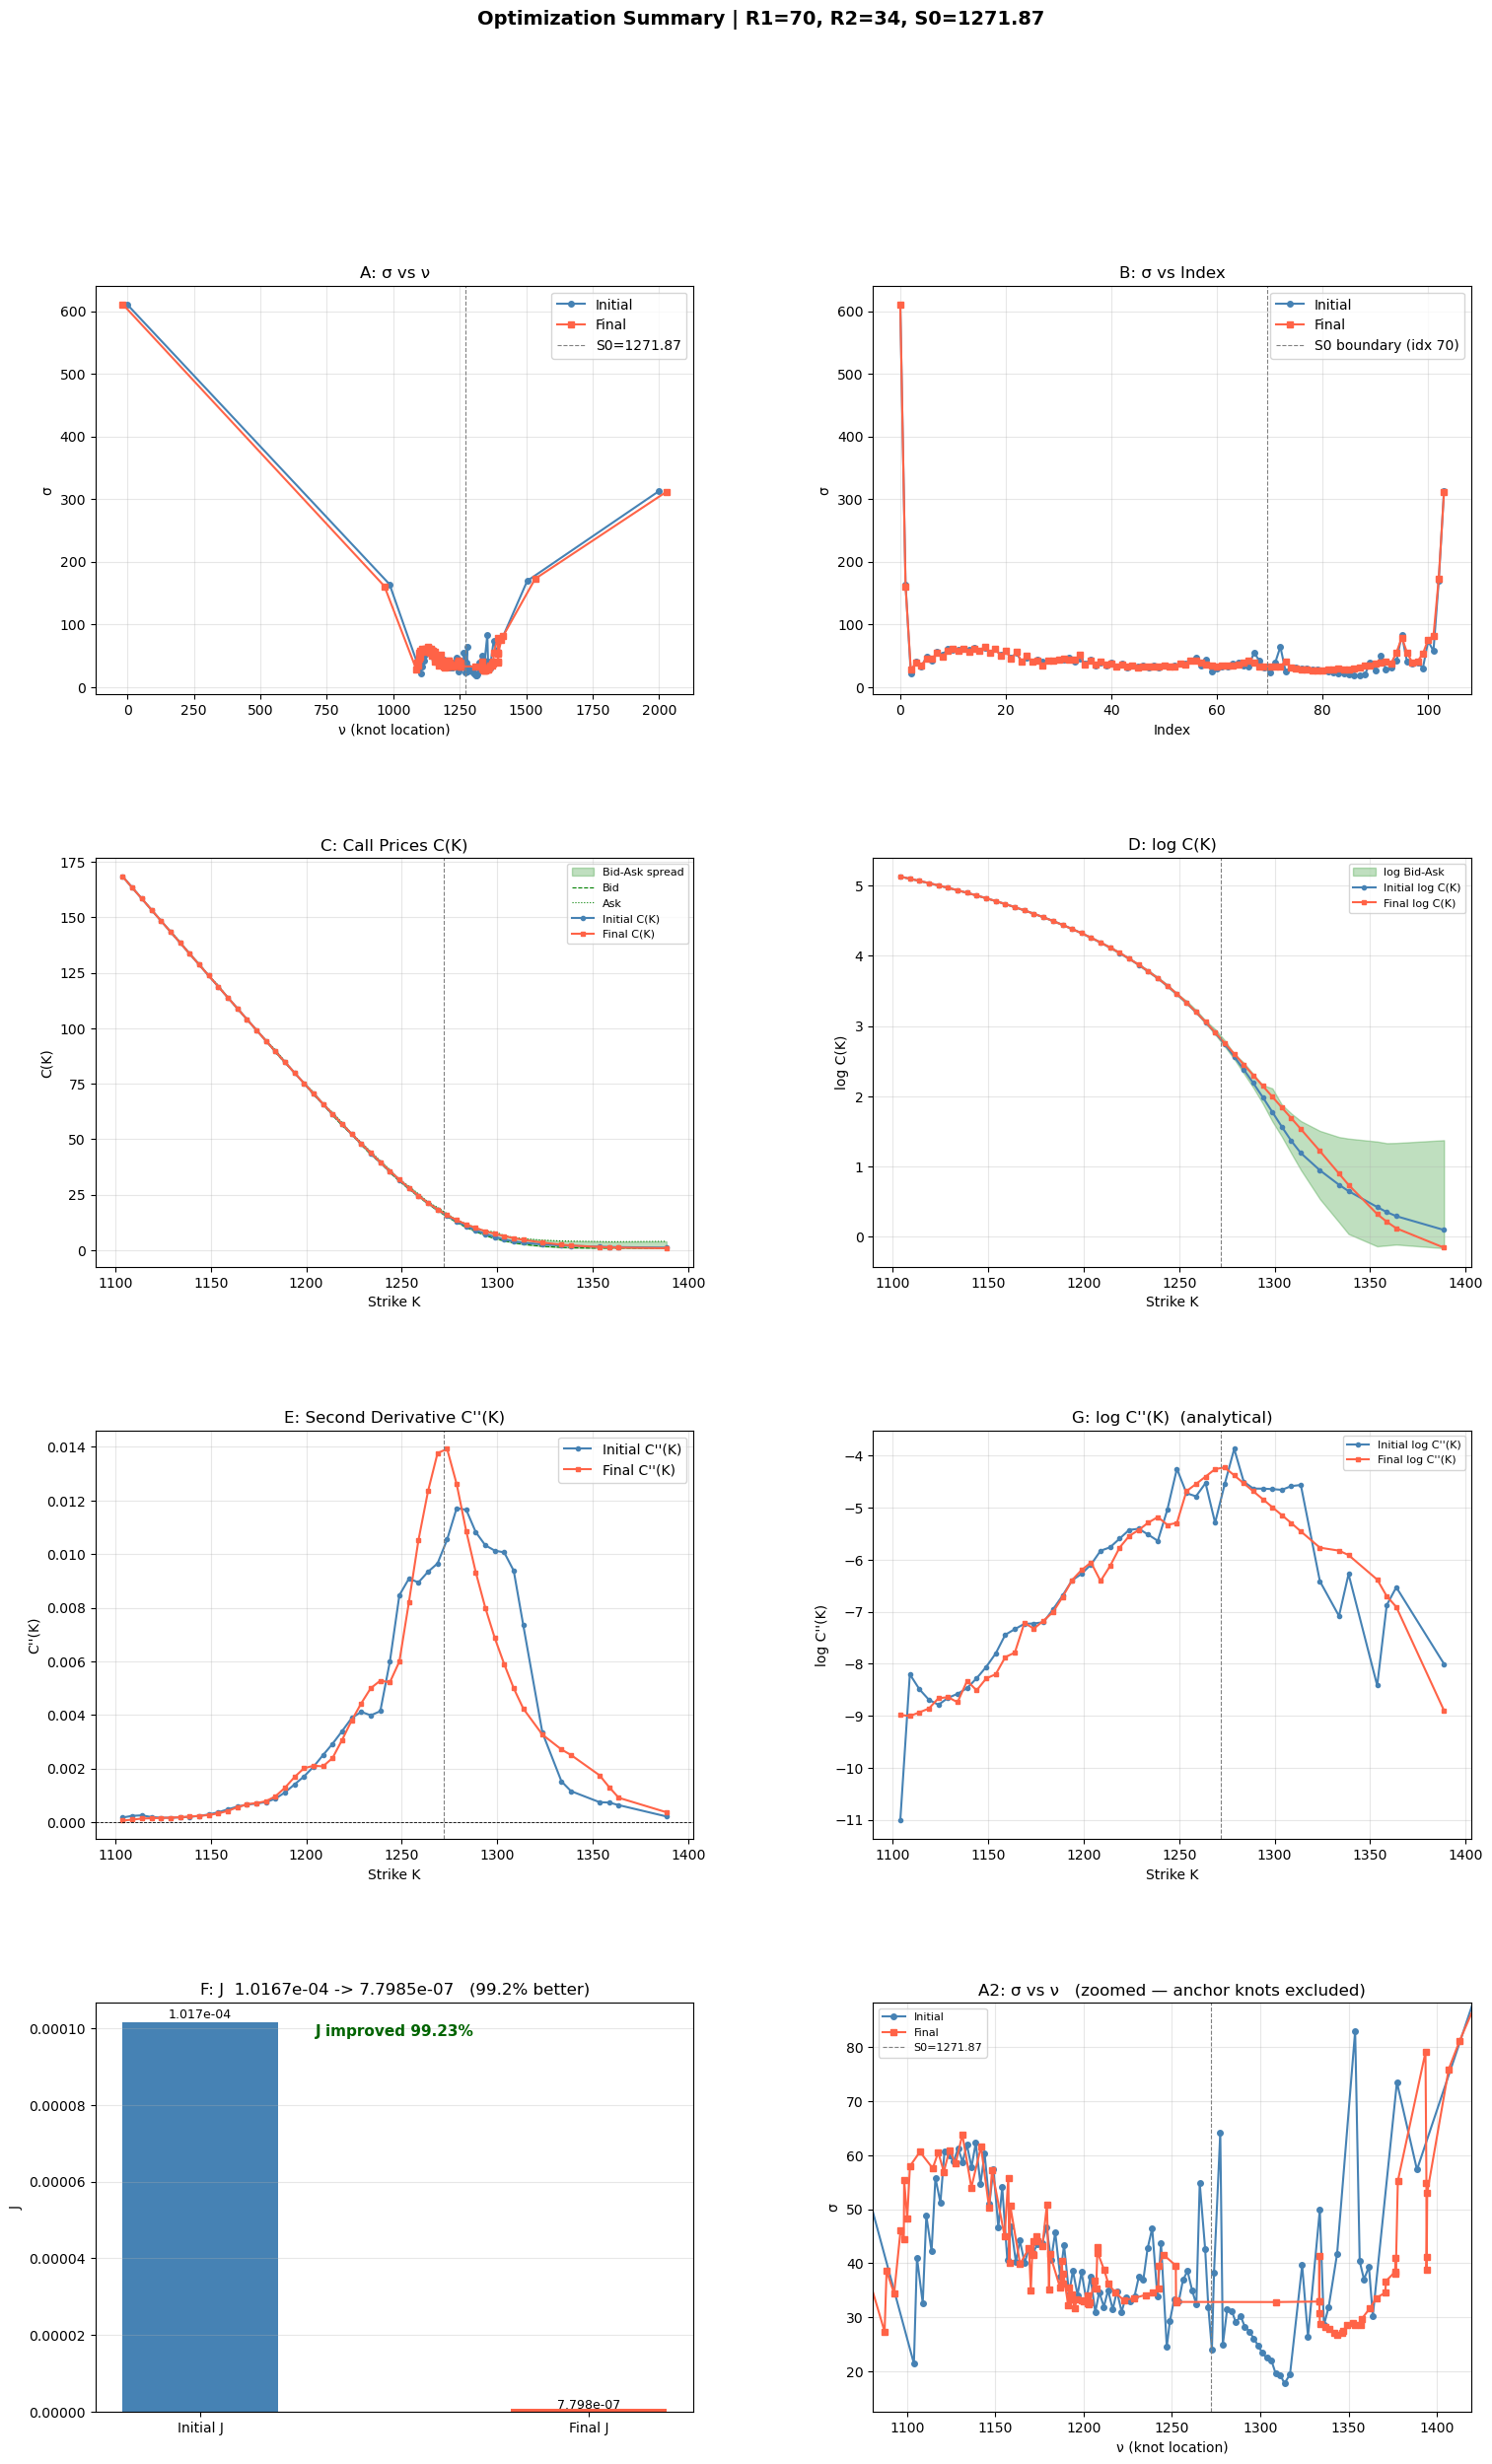

Saved optimization_summary.png


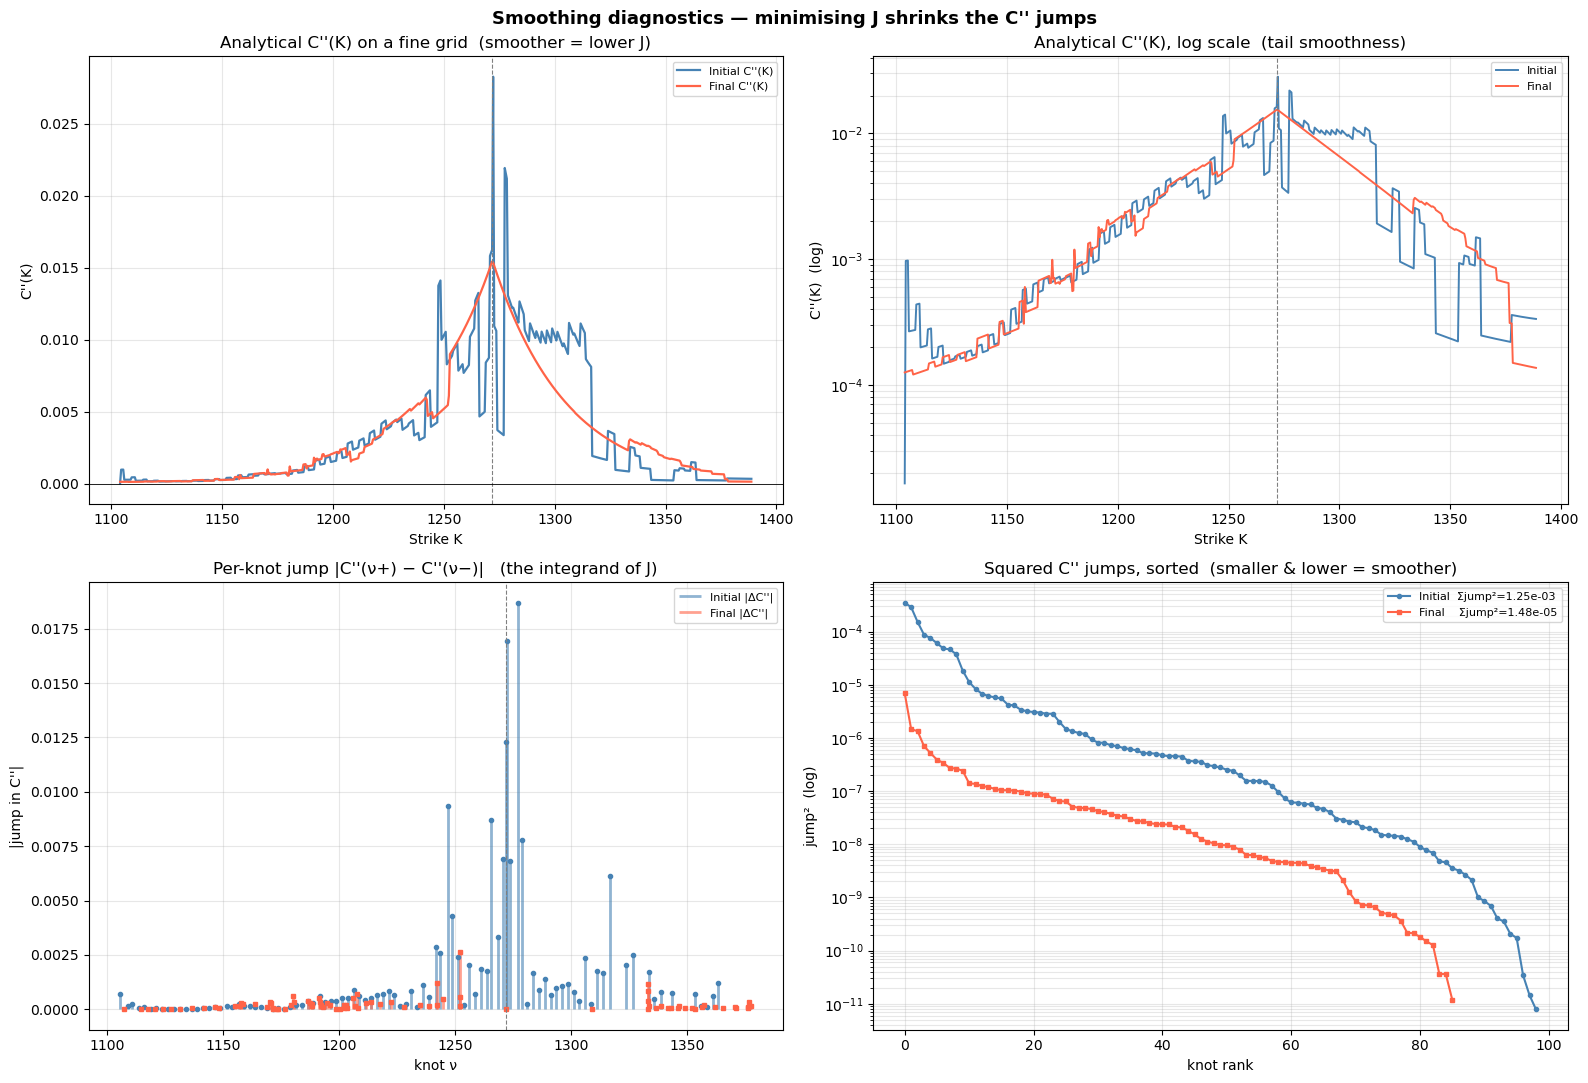

Saved smoothing_diagnostics.png


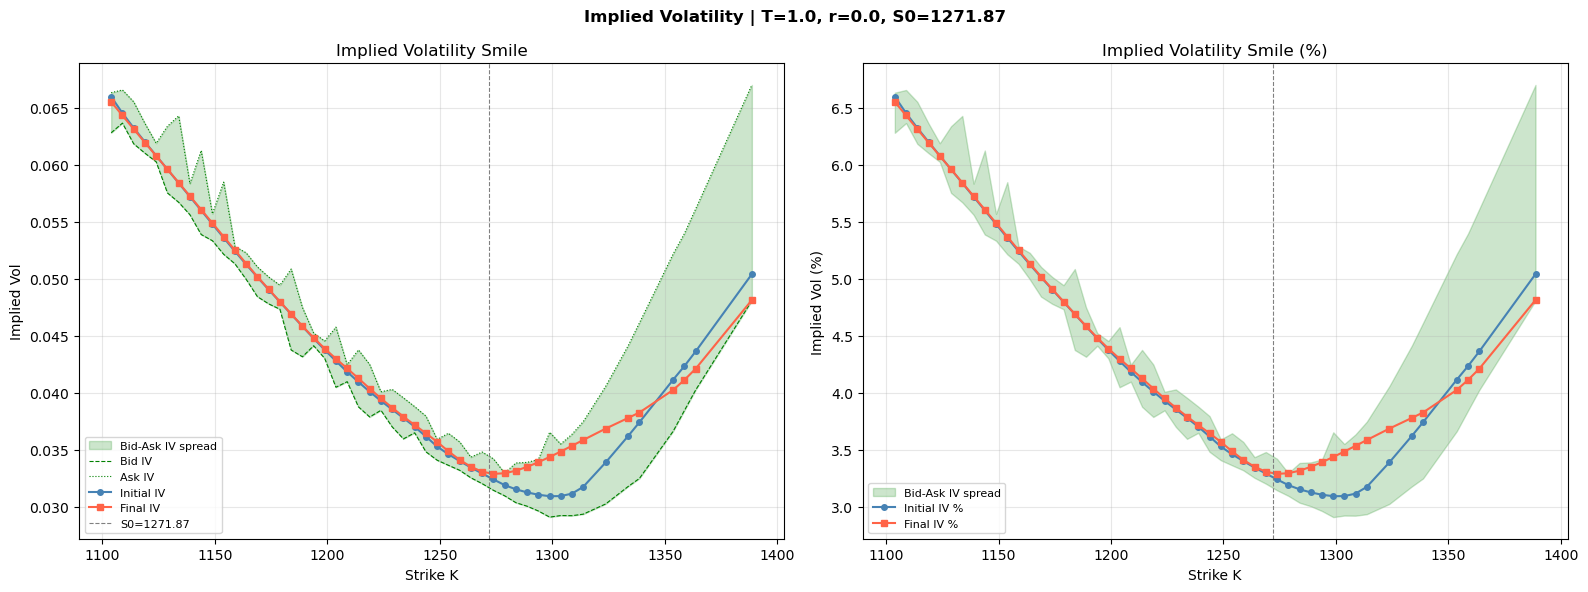


FINAL FITTED PARAMETERS (copy-paste ready for a warm start)
final_nus1  = [ -17.277236422317,  966.611815792108, 1087.304064150644, 1088.430525185886, 1092.703722335843, 1096.316923379325, 1098.170882033719, 1098.387267777539, 1100.111106007124, 1101.654913276997,
 1107.304665139033, 1114.559037117574, 1117.660179943789, 1120.854330813376, 1124.001139851331, 1127.566171520732, 1131.314140567577, 1136.431144175884, 1141.88005694158 , 1146.490683994369,
 1148.13508326131 , 1155.261130041209, 1157.345017780356, 1157.92988368904 , 1158.470637984607, 1164.006949374991, 1169.046696519725, 1170.093193592257, 1170.869225794929, 1171.484737775664,
 1171.779118671671, 1173.428668869916, 1173.812158053562, 1176.576246480078, 1179.224877832114, 1180.395354054423, 1180.818365331793, 1186.614354555371, 1187.609783793663, 1188.250087926319,
 1188.428845546275, 1191.311015375587, 1191.66827200602 , 1192.182564529031, 1193.109562077616, 1194.911809478179, 1196.110675993239, 1198.701599523224, 1200.306

/Users/zg0120/Desktop/Project1/local runs/fit_results_70x34_20260609_135342.csv

In [28]:
# Quotes.csv          : columns = [strike, ask, bid]   (no header)
# ArbFree_calls_strikes.csv : columns = [arb_free_price, strike] (no header)
bid_ask, market_prices, arb_strikes = load_market_data(
    "Quotes.csv", "ArbFree_calls_strikes.csv")

S0 = 1271.87          # spot
R1, R2 = 70, 34       # number of left / right knots (as in the original)

# Supply a FEASIBLE starting point: strictly-increasing knots with
# nus1[-1] < S0 < nus2[0] and all sigmas > 0.  (Any ordering / boundary /
# positivity errors in this start are silently repaired by the
# reparameterisation, so a rough guess is fine.)
# nus1  = torch.linspace(S0 - 400.0, S0 - 5.0, R1)
# nus2  = torch.linspace(S0 + 5.0, S0 + 500.0, R2)
# sigs1 = torch.full((R1,), 100.0)
# sigs2 = torch.full((R2,), 100.0)

initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

nus1 = torch.tensor(initial_nus1, dtype=torch.float64)
sigs1 = torch.tensor(initial_sigs1, dtype=torch.float64)
nus2 = torch.tensor(initial_nus2, dtype=torch.float64)
sigs2 = torch.tensor(initial_sigs2, dtype=torch.float64)


theta_final = run_and_plot(
    R1, R2, S0, sigs1, sigs2, nus1, nus2,
    calculate_J, generate_call_prices, bid_ask,
    max_outer=80,
    # How to weight J's per-knot C'' jumps (on top of the base 1/time_value):
    #   "none"    -> jump^2 / time_value                              (original)
    #   "spread"  -> ... * (spread/median_spread)^spread_power
    #   "spacing" -> ... * (Δν/median_Δν)^spacing_power   (mesh-independent)
    #   "both"    -> ... * spread_factor * spacing_factor
    weighting="spacing",
    spread_power=1.0, spacing_power=1.0)

The two test files (`Quotes.csv`, `ArbFree_calls_strikes.csv`) were *derived* from a raw
WRDS/OptionMetrics export. `make_test_files_from_wrds` reproduces that derivation for **any**
OptionMetrics options file (columns `date, exdate, cp_flag, strike_price, best_bid, best_offer, …`)
and writes the same two CSVs. The steps:

1. **Pick one option chain** — a single `(date, exdate)` pair (one trade date + one expiry).
2. **Strikes** — OptionMetrics stores `strike_price ×1000`, so `K = strike_price/1000`.
3. **Spot/forward `S0` via put–call parity** — for each strike quoted on *both* sides,
   `C−P = e^{−rT}(F−K)`. A line fit of `(C_mid − P_mid)` vs `K` gives slope `=−e^{−rT}` and
   intercept `= e^{−rT}F`, so we recover the **discount factor**, the **forward `F`** (used as `S0`),
   and the implied **`r`**. (No separate spot/rate file needed — they fall out of the option quotes.)
4. **Quotes file** — keep liquid calls (`bid>0`, `ask>bid`, inside a moneyness window),
   write `[strike, ask, bid]` exactly like `Quotes.csv`.
5. **Arbitrage-free file** — calls must be **non-increasing and convex** in `K` (and bounded by the
   intrinsic value). We solve a tiny constrained least-squares problem: the convex, decreasing curve
   **closest to the bid/ask mids**. That cleaned curve is the arb-free target, written `[price, strike]`
   like `ArbFree_calls_strikes.csv`.

The function returns the loaded tensors plus `S0`, `T`, `r`, and suggested `R1/R2`, so it drops
straight into `build_warm_start` + `run_and_plot`.

In [29]:
import numpy as np, pandas as pd

def make_test_files_from_wrds(csv_path, date=None, exdate=None,
                              moneyness=(0.85, 1.12), require_both_sides=True,
                              quotes_out="Quotes_SPX.csv", arbfree_out="ArbFree_SPX.csv",
                              df=None, verbose=True):
    """Turn a raw WRDS/OptionMetrics options export into the two CSVs this notebook
    consumes. Returns a dict with bid_ask, arb_prices, arb_strikes, S0, T, r, R1, R2,
    and the two output paths. See the markdown above for the method."""
    from scipy.optimize import minimize, LinearConstraint, Bounds

    if df is None:
        df = pd.read_csv(csv_path)
    # 1. choose a chain: default = first date, and the expiry with the most calls
    if date is None:
        date = int(df["date"].min())
    day = df[df["date"] == date]
    if exdate is None:
        ncall = day[day["cp_flag"] == "C"].groupby("exdate").size()
        exdate = int(ncall.idxmax())
    chain = df[(df["date"] == date) & (df["exdate"] == exdate)].copy()
    chain["K"]   = chain["strike_price"] / 1000.0
    chain["mid"] = 0.5 * (chain["best_bid"] + chain["best_offer"])
    T = (pd.to_datetime(str(exdate)) - pd.to_datetime(str(date))).days / 365.0

    calls = chain[chain["cp_flag"] == "C"][["K", "best_bid", "best_offer", "mid", "volume"]]
    puts  = chain[chain["cp_flag"] == "P"][["K", "mid", "best_bid"]].rename(
                columns={"mid": "pmid", "best_bid": "pbid"})

    # 3. put-call parity -> discount, forward F, implied r  (S0 := F)
    merged = calls.merge(puts, on="K")
    liq = merged[(merged["best_bid"] > 0) & (merged["pbid"] > 0)]
    slope, intercept = np.polyfit(liq["K"].values, (liq["mid"] - liq["pmid"]).values, 1)
    disc = -slope
    F    = intercept / disc
    r    = -np.log(disc) / T if T > 0 else 0.0
    S0   = float(F)

    # 4. liquid call quotes inside a moneyness window
    cc = calls[(calls["best_bid"] > 0) & (calls["best_offer"] > calls["best_bid"])]
    cc = cc[(cc["K"] >= moneyness[0] * F) & (cc["K"] <= moneyness[1] * F)].sort_values("K")
    K   = cc["K"].values.astype(float)
    bid = cc["best_bid"].values.astype(float)
    ask = cc["best_offer"].values.astype(float)
    mid = cc["mid"].values.astype(float)
    n   = len(K)

    # 5. arb-free = convex + non-increasing least-squares fit to the mids
    A_dec = np.zeros((n - 1, n))
    for i in range(n - 1):
        A_dec[i, i] = 1.0; A_dec[i, i + 1] = -1.0                 # p[i] - p[i+1] >= 0
    A_cvx = np.zeros((n - 2, n))
    for i in range(n - 2):
        h1, h2 = K[i + 1] - K[i], K[i + 2] - K[i + 1]
        A_cvx[i, i] = 1.0 / h1; A_cvx[i, i + 1] = -(1.0 / h1 + 1.0 / h2); A_cvx[i, i + 2] = 1.0 / h2
    cons = [LinearConstraint(A_dec, 0, np.inf), LinearConstraint(A_cvx, 0, np.inf)]
    lb   = disc * np.maximum(F - K, 0.0)                          # >= intrinsic (no-arb lower bound)
    ub   = np.full(n, disc * F)                                   # <= discounted forward
    res  = minimize(lambda p: np.sum((p - mid) ** 2), mid.copy(),
                    jac=lambda p: 2.0 * (p - mid), method="SLSQP",
                    constraints=cons, bounds=Bounds(lb, ub), options={"maxiter": 800, "ftol": 1e-12})
    arb = res.x

    # write the two CSVs in the original formats (no header)
    pd.DataFrame({"strike": K, "ask": ask, "bid": bid}).to_csv(quotes_out, index=False, header=False)
    pd.DataFrame({"price": arb, "strike": K}).to_csv(arbfree_out, index=False, header=False)

    # suggested knot counts: anchor + strikes + midpoints on each side of S0
    # Suggested knot counts. NOTE: too many knots (~2x strikes) makes the cold
    # warm-start pre-fit ill-conditioned (it can collapse the density), so we use a
    # conservative count ~ strikes + a third. Increase later if you want more detail.
    n_left  = int((K <= S0).sum()); n_right = int((K >= S0).sum())
    R1 = n_left + max(6, n_left // 3); R2 = n_right + max(6, n_right // 3)

    if verbose:
        inb = float(((arb >= bid - 1e-9) & (arb <= ask + 1e-9)).mean())
        print(f"chain {date} -> exp {exdate}  (T={T:.4f}y, {int(round(T*365))}d)")
        print(f"  put-call parity: disc={disc:.5f}, implied r={r:.4f}, forward S0={S0:.3f}")
        print(f"  kept {n} liquid calls in K=[{K.min():.0f}, {K.max():.0f}]  "
              f"({n_left} <= S0, {n_right} >= S0)  -> suggest R1={R1}, R2={R2}")
        print(f"  arb-free fit RMSE to mid = {np.sqrt(np.mean((arb-mid)**2)):.4f}, "
              f"{inb*100:.0f}% inside band")
        print(f"  wrote '{quotes_out}' [strike,ask,bid] and '{arbfree_out}' [price,strike]")

    bid_ask = torch.tensor(np.column_stack([K, bid, ask]), dtype=torch.float64)
    return {"bid_ask": bid_ask,
            "arb_prices": torch.tensor(arb, dtype=torch.float64),
            "arb_strikes": torch.tensor(K, dtype=torch.float64),
            "S0": S0, "T": T, "r": float(r), "R1": R1, "R2": R2,
            "quotes_path": quotes_out, "arbfree_path": arbfree_out}

In [30]:
# ── Process the raw WRDS file, then fit it end-to-end ────────────────────────
spx = make_test_files_from_wrds("SPX_opt_2011_2012.csv", date=20110103, exdate=20110122)

# Reload via the SAME loader used for Quotes.csv, to prove the files are well-formed.
bid_ask_spx, arb_p_spx, arb_K_spx = load_market_data(spx["quotes_path"], spx["arbfree_path"])
S0_spx, R1s, R2s = spx["S0"], spx["R1"], spx["R2"]

# Data-driven feasible warm start (fit to the arb-free target), then optimise + plot.
s1, s2, n1, n2 = build_warm_start(bid_ask_spx, S0_spx, R1s, R2s,
                                  target_prices=arb_p_spx, target_strikes=arb_K_spx)
# (max_outer=25 takes ~1-2 min here; it is usually fully in-band and ~85%
#  smoother within the first dozen outer iterations.)
# theta_spx = run_and_plot(R1s, R2s, S0_spx, s1, s2, n1, n2,
#                          calculate_J, generate_call_prices, bid_ask_spx,
#                          max_outer=25)

chain 20110103 -> exp 20110122  (T=0.0521y, 19d)
  put-call parity: disc=0.99873, implied r=0.0245, forward S0=1270.919
  kept 61 liquid calls in K=[1085, 1390]  (38 <= S0, 23 >= S0)  -> suggest R1=50, R2=30
  arb-free fit RMSE to mid = 0.0510, 93% inside band
  wrote 'Quotes_SPX.csv' [strike,ask,bid] and 'ArbFree_SPX.csv' [price,strike]
[warm start] R1=50 R2=30 | RMSE to target = 0.03489 | J = 0.0002083 | min C'' = 4.02e-05 | band violation = 8.916e-02  (NOT yet in band (Phase-0/AL will finish it))


### C''(K) plots

- Numerical C''(K) (`compute_second_derivative`): `np.gradient(np.gradient(C, K), K)` — finite differences of the fitted prices at the actual market strikes. It's an approximation whose error depends on the (coarse, uneven) strike spacing, so it's noisy/jagged.

- Analytical C''(K) (`C2_K`): the exact closed-form second derivative of the model, using the formula. This is the quantity J actually controls.

### the last smoothing-diagnostics panel (bottom-right)

It plots jump^2 (y, log scale) vs. knot rank (x). 

take the per-knot squared C'' jumps, sort them in descending order, and plot them

"knot rank" = position in that sorted list — rank 0 is the single largest jump^2, rank 1 the next, etc. It's a "where does the roughness live" profile; the whole final curve lying lower/left of the initial means total roughness fell.

Why the final curve ends earlier (fewer points): the panel only counts knots strictly inside the quoted-strike range and runs them through np.unique. After optimization the knots move — some right-side knots drift past the last strike (e.g. the SPX fit had a cluster near 1394 > max strike 1390, plus the 1909 anchor), and several knots collapse onto near-identical locations — so fewer distinct, in-range final knots survive the filter than initial ones. It's a minor artifact of the diagnostic's filtering plus genuine knot movement/collapse, not a problem with the fit. (On the original Quotes data, where knots barely move, initial and final both have 79 and the curves are the same length.)